# Which delivered orders may miss the promised date?

At checkout, can we identify delivered orders that are more likely to arrive after the promised date? We build a simple starting point, compare logistic regression and trees on later orders, and then ask whether the risk scores could help a delivery team choose which orders to review. After fixing the model choices on validation data, we make one final check on later test orders. A [short glossary](#A-short-glossary) is below.


## A short glossary

These terms appear in the results. You can return here as you read.

| Term | Meaning |
|---|---|
| Baseline | A starting model that gives every order the same risk: the late rate among its training orders. It cannot tell which orders are riskier. |
| Precision | Of the orders flagged, the share that really arrive late. |
| Recall | Of all late orders, the share flagged or put on a review list. |
| PR-AUC (average precision) | How well late orders rise toward the top of a risk ranking. The late share is the reference for a ranking with no useful separation. |
| ROC-AUC | How often a late order ranks above an on-time order. Chance is 0.5. |
| MCC | A summary of correct alerts, false alerts, missed late orders and correct non-alerts. Zero is roughly chance; one is perfect. |
| Lift | How many times more late orders a review list finds than a random list of the same size. |

Model comparisons use the **mean of five separate date-ordered validation scores**. When we combine predictions from those five periods into one set, we call the result **pooled**. The two are not interchangeable.


## 1. What we predict

A delivery team could check orders that look likely to miss their promised date. An order counts as **late** when its actual delivery *date* is after its estimated delivery date. Delivery on the estimated date is on time.

We study orders that were eventually delivered. Cancellation and non-delivery are separate problems. We act as though the risk is estimated just after checkout, before approval, shipping or a customer review.


We first load the tools, locate the project files and declare the model settings to be compared. The printed count is a check that the full candidate list is present; nothing is fitted yet.


In [1]:
from pathlib import Path
import json, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             matthews_corrcoef, precision_score, recall_score,
                             roc_auc_score, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
if not (ROOT / "data/phase2_feature_spec.json").exists():
    ROOT = ROOT.parents[1]
RESULT_DIR = ROOT / "results/phase2/classification"
MODEL_FAMILIES = {"dummy": "baseline", "linear": "linear", "tree": "tree_based", "forest": "tree_based"}

CANDIDATES = [
    ("prior_baseline", "dummy", {}),
    ("logistic_baseline", "linear", {"C": 1.0, "class_weight": None}),
    ("logistic_c01", "linear", {"C": 0.1, "class_weight": None}),
    ("logistic_c10", "linear", {"C": 10.0, "class_weight": None}),
    ("logistic_balanced", "linear", {"C": 1.0, "class_weight": "balanced"}),
    ("tree_baseline", "tree", {"max_depth": None, "min_samples_leaf": 1}),
    ("tree_depth6", "tree", {"max_depth": 6, "min_samples_leaf": 50}),
    ("tree_depth12", "tree", {"max_depth": 12, "min_samples_leaf": 20}),
    ("tree_balanced", "tree", {"max_depth": 12, "min_samples_leaf": 20, "class_weight": "balanced"}),
    ("forest_baseline", "forest", {"max_depth": None, "min_samples_leaf": 1}),
    ("forest_depth12", "forest", {"max_depth": 12, "min_samples_leaf": 20}),
    ("forest_leaf20", "forest", {"max_depth": None, "min_samples_leaf": 20}),
    ("forest_balanced", "forest", {"max_depth": None, "min_samples_leaf": 20, "class_weight": "balanced_subsample"}),
]

BASE = "#88919b"; LINEAR = "#266f9b"; FOREST = "#d28439"; LATE = "#b44548"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})
print(f"Project root: {ROOT}")
print(f"Declared candidate models: {len(CANDIDATES)}")

/Users/joshualum/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/lh/h9px96k96s33hykt549wrwv00000gn/T/matplotlib-ua4f6qtb because there was an issue with the default path (/Users/joshualum/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/joshualum/Documents/VSCode/IT5006_Grp_6
Declared candidate models: 13


The project root was found and the planned candidates are declared. Now we need a rule for which facts a checkout-time prediction may use.


This timeline marks the **prediction moment**. For the order being scored, we may use checkout information and earlier orders whose relevant events have already happened. We cannot use this order's later approval, handover, delivery or review. Those would reveal part of the answer we are trying to predict.


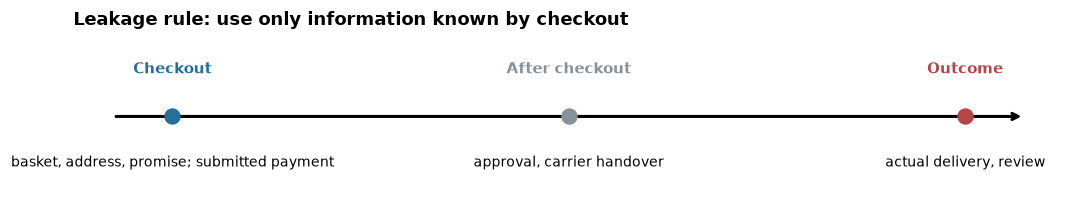

**How to read this.** The first stop is information we may use for this order. Approval, handover, delivery and review happen later, so they cannot be used to predict this order at checkout. A seller or route summary is allowed only when it comes from earlier orders already completed by this purchase.

In [2]:
fig, ax = plt.subplots(figsize=(10, 2.1))
ax.set_xlim(0, 10); ax.set_ylim(-0.7, 1); ax.axis("off")
ax.annotate("", xy=(9.6, 0.2), xytext=(0.4, 0.2), arrowprops={"arrowstyle": "->", "lw": 2})
for x, title, note, colour in [(1, "Checkout", "basket, address, promise; submitted payment", LINEAR),
                               (5, "After checkout", "approval, carrier handover", BASE),
                               (9, "Outcome", "actual delivery, review", LATE)]:
    ax.scatter([x], [.2], s=95, color=colour, zorder=3)
    ax.text(x, .62, title, ha="center", weight="bold", color=colour)
    ax.text(x, -.18, note, ha="center", va="top", fontsize=9)
ax.set_title("Leakage rule: use only information known by checkout", loc="left")
plt.tight_layout(); plt.show()
display(Markdown("**How to read this.** The first stop is information we may use for this order. Approval, handover, delivery and review happen later, so they cannot be used to predict this order at checkout. A seller or route summary is allowed only when it comes from earlier orders already completed by this purchase."))

The diagram sets the timing rule. The prepared feature list and the date checks below show how we apply it.


## 2. Where this notebook starts

[data_prep.ipynb](data_prep.ipynb) joined the separate Olist tables into one row per order. It combined items and payments, added customer, seller and product details, estimated distance from ZIP-area centres, and built route and seller history using earlier completed events. It kept orders with both an actual and promised delivery date; cancelled and unfinished orders have no late label here. Its [excluded-features table](data_prep.ipynb#features-excluded-by-rule) lists columns rejected by rule.

This notebook starts with that prepared table. The next cell loads **training rows only** and checks that neither a reserved test order nor an outcome/date-split column can enter the model inputs. Missing numeric values will be filled later *inside* each training pipeline, so the validation period cannot teach the model how to fill them.


In [3]:
def load_primary_training(root=ROOT):
    root = Path(root)
    spec = json.loads((root / "data/phase2_feature_spec.json").read_text())
    table = pd.read_csv(
        root / "data/phase2_order_table.csv",
        parse_dates=["order_purchase_timestamp", "outcome_available_at"],
    )
    # Select the agreed training population before any statistics or fitting.
    train = table.loc[table[spec["primary_split"]].eq("train")].reset_index(drop=True)
    if not train["order_id"].is_unique:
        raise ValueError("Primary training must have unique order IDs")
    cutoff = pd.Timestamp(spec["primary_cutoff"])
    if not (train["order_purchase_timestamp"].lt(cutoff).all()
            and train["outcome_available_at"].lt(cutoff).all()):
        raise ValueError("Primary training contains an order unavailable at the cutoff")
    features = spec["numeric_features"] + spec["categorical_features"]
    forbidden = {spec["classification_target"], spec["regression_target"], "order_id",
                 "outcome_available_at", "order_purchase_timestamp", "furthest_seller_id", "split", "cv_fold",
                 "random_split", "random_cv_fold"}
    if len(features) != len(set(features)) or forbidden.intersection(features):
        raise ValueError("Invalid predictor contract")
    assert set(features).issubset(train.columns), "A contract feature is missing"
    assert train[spec["primary_split"]].eq("train").all(), "Test rows entered training"
    reference = json.loads((root / "results/phase2/classification/selection.json").read_text())
    assert len(train) == reference["train_orders"], "Training population changed"
    metadata = {"prepared_orders": len(table), "training_orders": len(train)}
    return train, spec, metadata

train, spec, preparation_counts = load_primary_training(ROOT)
print(f"Eligible primary training orders: {len(train):,}")
print(f"Late orders: {train[spec['classification_target']].sum():,} ({train[spec['classification_target']].mean():.1%})")
print("Predictors:", len(spec["numeric_features"] + spec["categorical_features"]))
summary_items = [
    ("Population", f"{preparation_counts['prepared_orders']:,} prepared delivered orders; {len(train):,} eligible primary training orders"),
    ("Late label", spec["classification_rule"] + "; delivery on the promised date is on time"),
    ("Inputs", f"{len(features := spec['numeric_features'] + spec['categorical_features'])} checkout-time candidate inputs; availability remains an assumption"),
    ("History", spec["history_features"]["rule"]),
    ("Partitions", f"Cutoff {spec['primary_cutoff']}; {spec['validation_maturity_days']}-day gap before test; {spec['n_folds']} validation windows; test reserved"),
]
display(pd.DataFrame(summary_items, columns=["Prepared decision", "Meaning"]).style.hide(axis="index"))
print("Verified feature list:", features)


Eligible primary training orders: 75,099
Late orders: 5,334 (7.1%)
Predictors: 20


Prepared decision,Meaning
Population,"96,470 prepared delivered orders; 75,099 eligible primary training orders"
Late label,actual delivery calendar date > estimated delivery calendar date; delivery on the promised date is on time
Inputs,20 checkout-time candidate inputs; availability remains an assumption
History,each order uses only earlier orders whose delivery (route) or carrier handover (seller) was recorded before its purchase
Partitions,Cutoff 2018-05-26; 60-day gap before test; 5 validation windows; test reserved


Verified feature list: ['promised_days', 'promise_slack', 'route_typical_days', 'seller_ship_days', 'distance_km', 'same_state', 'purchase_hour', 'n_items', 'n_products', 'n_sellers', 'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'max_installments', 'customer_state', 'seller_state', 'product_category', 'payment_type', 'purchase_dayofweek']


The table shows the training population, late share, feature count and split rule. The printed input list is the actual set offered to the models. The checks above passed: no reserved test row, delivery outcome or split label is in the training inputs. This is a necessary leakage check, though whether every source field was truly available at checkout remains an assumption.


## 3. What information might help?

Before building models, we look for plausible clues in **earlier training orders only**. The charts can reveal patterns or explain a feature, but they cannot show that adding it improves predictions. Section 8 makes that judgement on later validation orders.

We already have checkout details about the order and its route: size and value, an estimated seller-to-customer distance, purchase time, promised delivery time, and possibly payment details. Distance is based on ZIP-area centres, so it is approximate. We also built three features from earlier completed orders. The next table shows how much resolved history was available before each validation period. We use the history before the final period for the descriptive plots.


In [4]:
training_snapshots = []
for window in range(spec["n_folds"]):
    boundary = train.loc[train[spec["primary_fold"]].eq(window), "order_purchase_timestamp"].min()
    snapshot = train.loc[train.order_purchase_timestamp.lt(boundary)
                         & train.outcome_available_at.lt(boundary)].copy()
    assert snapshot.order_purchase_timestamp.lt(boundary).all()
    assert snapshot.outcome_available_at.lt(boundary).all()
    assert not snapshot[spec["primary_fold"]].eq(window).any()
    training_snapshots.append(snapshot)
feature_train = training_snapshots[-1]
display(pd.DataFrame({"upcoming window": range(spec["n_folds"]),
                      "earlier training orders": [len(s) for s in training_snapshots],
                      "training late rate": [s.is_late.mean() for s in training_snapshots]})
        .style.format({"training late rate": "{:.1%}"}).hide(axis="index"))


upcoming window,earlier training orders,training late rate
0,23695,3.1%
1,30987,3.3%
2,36197,3.3%
3,45014,5.0%
4,52198,5.0%


Each row shows what was already known before a validation period began. The growing number of resolved orders gives later models more history to learn from. The late rate also moves, which is one reason to check performance in several later periods rather than trust one average.


We first look at three familiar checkout clues: **distance**, **time promised** and **number of sellers**. In each panel, orders are grouped by that clue. The bar is the share of the group that later arrived late; the dashed line is the late share across this whole earlier training set. This is a quick picture of association, not a model score.


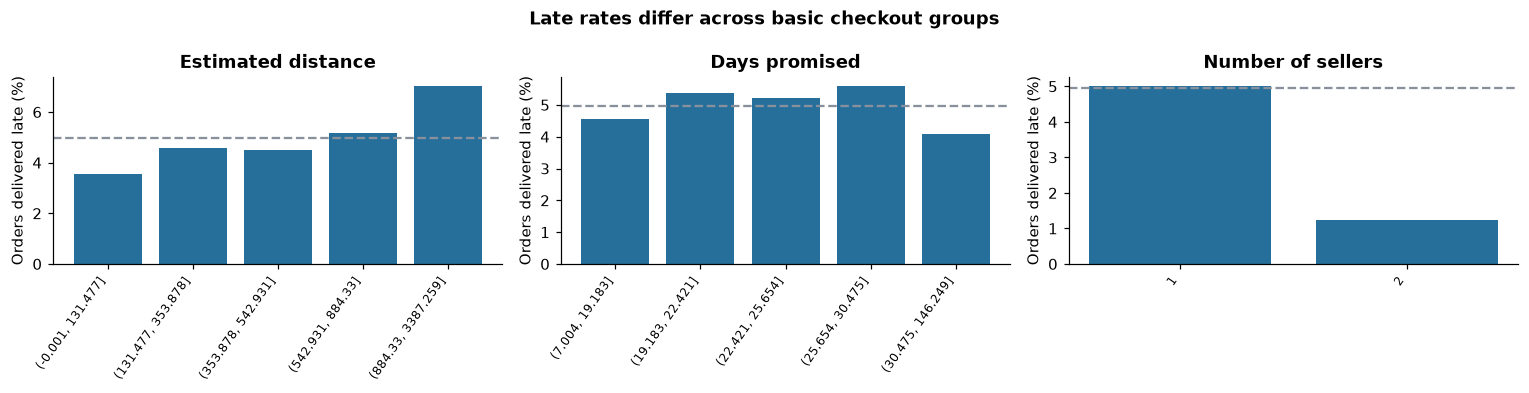

Three examples shown from 17 original candidate inputs; groups with fewer than 100 orders are omitted.


In [5]:
def descriptive_rates(frame, feature):
    values = frame[feature]
    if feature in ["n_items", "n_products", "n_sellers"]:
        groups = values.clip(upper=4).astype(str)
        order = sorted(groups.unique(), key=float)
    elif pd.api.types.is_numeric_dtype(values) and values.nunique() > 8:
        bins = pd.qcut(values, q=5, duplicates="drop")
        groups = bins.astype(str)
        order = [str(category) for category in bins.cat.categories]
    else:
        groups = values.fillna("Missing").astype(str)
        order = sorted(groups.unique())
    groups = groups.where(values.notna(), "Missing")
    stats = frame.groupby(groups, observed=True).is_late.agg(["mean", "size"])
    if not pd.api.types.is_numeric_dtype(values):
        order = stats["size"].nlargest(6).index.tolist()
    stats = stats.reindex([label for label in order if label in stats.index])
    return stats.loc[stats["size"].ge(100)]

original_features = [f for f in features if f not in spec["history_features"]["features"]]
examples = [("distance_km", "Estimated distance"),
            ("promised_days", "Days promised"),
            ("n_sellers", "Number of sellers")]
fig, axes = plt.subplots(1, len(examples), figsize=(14, 3.6))
for ax, (feature, title) in zip(axes, examples):
    rates = descriptive_rates(feature_train, feature)
    ax.bar(range(len(rates)), rates["mean"] * 100, color=LINEAR)
    ax.axhline(feature_train.is_late.mean() * 100, color=BASE, ls="--")
    ax.set_xticks(range(len(rates)), rates.index, rotation=55, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Orders delivered late (%)")
fig.suptitle("Late rates differ across basic checkout groups", weight="bold")
plt.tight_layout(); plt.show()
print(f"Three examples shown from {len(original_features)} original candidate inputs; groups with fewer than 100 orders are omitted.")


In this training snapshot, **the longest-distance group has a higher late share** than the shortest-distance group. The promised-time bars do not rise steadily, and the two-seller group has a lower observed late share than the one-seller group. Those are descriptions of these groups, not explanations of *why* orders are late. They also do not prove that any one clue improves a model. We keep the original checkout inputs as candidates and test them together on later orders.


### When inputs overlap

The next heatmap compares numeric **inputs with one another**, not with lateness. Red squares mean two inputs tend to rise together; blue squares mean one tends to fall as the other rises. We look for overlap because later coefficient and importance charts can split credit between related inputs. Correlation does not, by itself, tell us to delete either input.


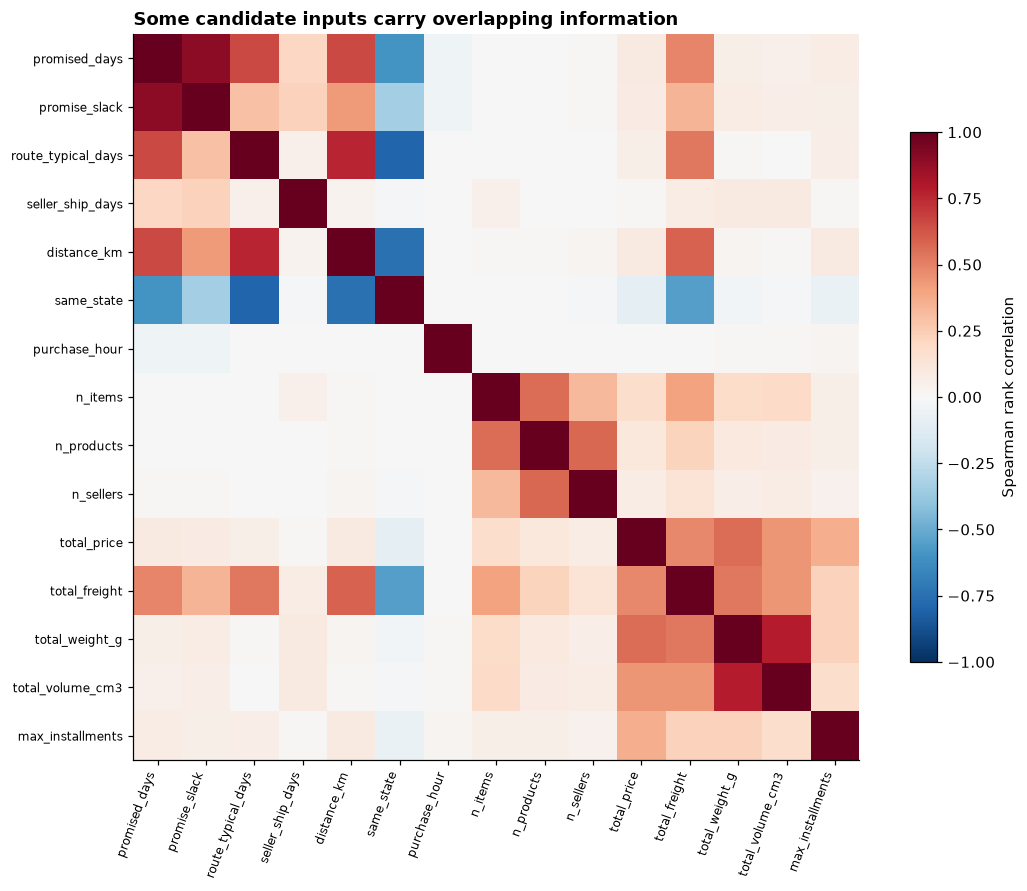

**Strongest pairs in this training history:** `promised_days` with `promise_slack` (+0.89); `route_typical_days` with `same_state` (-0.80); `total_weight_g` with `total_volume_cm3` (+0.78); `route_typical_days` with `distance_km` (+0.76); `distance_km` with `same_state` (-0.75).

In [6]:
correlation = feature_train[spec["numeric_features"]].corr(method="spearman")
corr = correlation.astype(float)
fig, ax = plt.subplots(figsize=(10.5, 8.2))
mat = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.index)), corr.index, fontsize=8)
fig.colorbar(mat, ax=ax, shrink=.73, label="Spearman rank correlation")
ax.set_title("Some candidate inputs carry overlapping information", loc="left")
plt.tight_layout(); plt.show()
strong = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong = strong[strong.abs() >= .4].sort_values(key=lambda s:s.abs(), ascending=False)
display(Markdown("**Strongest pairs in this training history:** " + "; ".join(
    f"`{a}` with `{b}` ({v:+.2f})" for (a,b),v in strong.head(5).items()) + "."))


The strongest pair is **promised days and promise slack**. That is expected: slack is calculated as promised days minus usual route time. Weight and volume also tend to rise together. The promise, route-time and slack trio is especially intertwined, so a logistic coefficient for any one of them cannot be read as its isolated effect. Logistic regression can still use related inputs for prediction; its regularisation helps keep fitted weights under control. We return to this caution when interpreting the fitted models.


### Three clues from earlier completed orders

- **Usual route time (`route_typical_days`):** the seller-state-to-customer-state route's earlier delivery time. Only orders delivered *before this purchase* count. With little route history, the estimate leans toward the earlier overall average.
- **Promise slack (`promise_slack`):** promised days minus usual route time. A more generous promise might make a miss less likely.
- **Past seller handover time (`seller_ship_days`):** how long this seller took to pass earlier parcels to a carrier, using only handovers completed before this purchase. For multi-seller orders, the preparation uses the furthest seller as a simplification.

The tiny made-up example below checks the most easily missed timing rule. An order bought earlier is **not** usable route history until it has actually arrived. The example explains the calculation; it is not part of model training.


In [7]:
example = pd.DataFrame({
    "order": ["A", "B", "C", "D"], "route": ["SP → RJ", "SP → RJ", "SP → MG", "SP → RJ"],
    "purchase": pd.to_datetime(["2017-01-01", "2017-01-03", "2017-01-04", "2017-01-15"]),
    "delivered": pd.to_datetime(["2017-01-11", "2017-01-23", "2017-01-12", None]),
})
query = example.iloc[-1]
earlier = example.loc[example.delivered.lt(query.purchase)].copy()
earlier["days"] = (earlier.delivered - earlier.purchase).dt.total_seconds() / 86400
route_history = earlier.loc[earlier.route.eq(query.route), "days"]
prior_weight = spec["history_features"]["route_prior_strength"]
typical = (route_history.sum() + prior_weight * earlier.days.mean()) / (len(route_history) + prior_weight)
display(example.style.hide(axis="index"))
print(f"At D's purchase, usable deliveries: {', '.join(earlier.order)}; B is still in transit.")
print(f"Illustrative route estimate: ({route_history.sum():.1f} + {prior_weight} × {earlier.days.mean():.1f}) / "
      f"({len(route_history)} + {prior_weight}) = {typical:.2f} days.")


order,route,purchase,delivered
A,SP → RJ,2017-01-01 00:00:00,2017-01-11 00:00:00
B,SP → RJ,2017-01-03 00:00:00,2017-01-23 00:00:00
C,SP → MG,2017-01-04 00:00:00,2017-01-12 00:00:00
D,SP → RJ,2017-01-15 00:00:00,NaT


At D's purchase, usable deliveries: A, C; B is still in transit.
Illustrative route estimate: (10.0 + 20 × 9.0) / (1 + 20) = 9.05 days.


When D is purchased, A and C have arrived but B is still travelling. Only A is both finished **and on D's route**. Using B's eventual delivery time would look into D's future. The route estimate blends A's time with the earlier overall average because one finished route order is thin evidence.


Do the new clues at least point in a sensible direction? The next figure compares their values for orders that later arrived **on time** (grey) and **late** (red). The line inside each box is the median; the box covers the middle half of that group. Look for a shift between groups, then look at how much they still overlap. The plot uses training orders only.


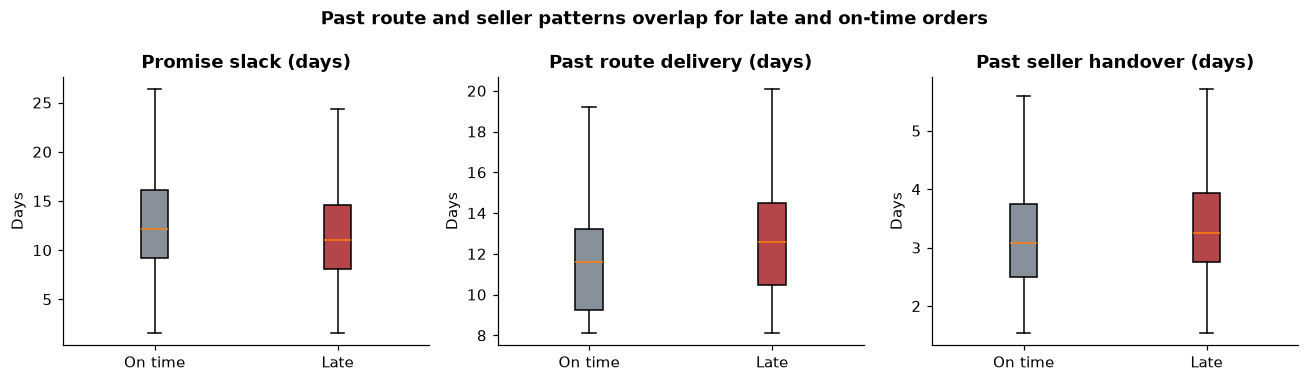

In [8]:
wanted = ["promise_slack", "route_typical_days", "seller_ship_days"]
training_view = feature_train[["is_late", *wanted]].copy()
labels = {"promise_slack":"Promise slack (days)", "route_typical_days":"Past route delivery (days)",
          "seller_ship_days":"Past seller handover (days)"}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, feature in zip(axes, wanted):
    values = training_view[feature].dropna()
    low, high = values.quantile([.01, .99])
    samples = [training_view.loc[training_view.is_late.eq(cls), feature].clip(low, high).dropna()
               for cls in [0,1]]
    box = ax.boxplot(samples, patch_artist=True, showfliers=False, tick_labels=["On time", "Late"])
    for patch, color in zip(box["boxes"], [BASE, LATE]): patch.set_facecolor(color)
    ax.set_title(labels[feature]); ax.set_ylabel("Days")
fig.suptitle("Past route and seller patterns overlap for late and on-time orders", weight="bold")
plt.tight_layout(); plt.show()


The late group has slightly **less promise slack**, **longer past route times** and **slower past seller handovers**. The boxes overlap heavily, so none of these clues tells us which individual order will be late. This is enough to motivate trying them; the feature ladder in Section 8 tests whether they improve predictions on later orders. We next explain the month, payment and large-number choices before fitting the models.


### Month, payment and large numbers

We will make three choices in the modelling comparison. **Purchase month** is known at checkout, but the record is too short to establish a repeatable seasonal pattern: it has at most one earlier year for a given month. A chart of these months cannot tell us whether an unusual November would recur. We therefore compare models with and without month on later validation periods.

**Payment method and instalments** remain candidates, but the source does not timestamp when those rows became available. Later we rerun the leading models without payment to see whether our results rely on that assumption.

For **large numeric values**, we try `log1p` in logistic regression. It maps a value to the log of one plus that value, squeezing the high end. This is not required to make logistic inputs normal; it may make the relationship easier for a linear model to use. The next display uses price as one concrete example. It shows the same training orders before and after the transform, then reports skewness for all five candidates. Validation later decides whether the transformed inputs actually help.


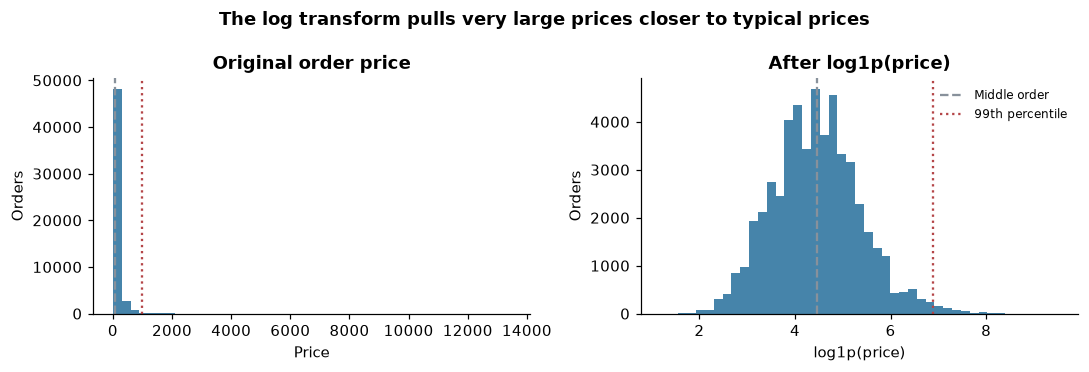

Input,Original skewness,After log1p
total_price,11.78,0.29
total_freight,8.51,1.19
distance_km,1.64,-1.09
total_weight_g,6.44,0.41
total_volume_cm3,7.75,-0.03


In [9]:
price = feature_train["total_price"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, values, title in zip(axes, [price, np.log1p(price)],
                             ["Original order price", "After log1p(price)"]):
    ax.hist(values, bins=45, color=LINEAR, alpha=.85)
    ax.axvline(values.quantile(.5), color=BASE, ls="--", label="Middle order")
    ax.axvline(values.quantile(.99), color=LATE, ls=":", label="99th percentile")
    ax.set_title(title)
    ax.set_xlabel("Price" if ax is axes[0] else "log1p(price)")
    ax.set_ylabel("Orders")
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle("The log transform pulls very large prices closer to typical prices", weight="bold")
plt.tight_layout(); plt.show()
skew = pd.DataFrame([
    {"Input": feature, "Original skewness": feature_train[feature].dropna().skew(),
     "After log1p": np.log1p(feature_train[feature].dropna()).skew()}
    for feature in spec["linear_log_candidates"]
])
display(skew.style.format({"Original skewness": "{:.2f}", "After log1p": "{:.2f}"}).hide(axis="index"))


The price example shows the long right tail on the original scale and a much shorter one after `log1p`. The dashed line marks the middle order; the dotted line marks the 99th percentile. The two horizontal axes use **different units**, so compare the shapes, not the printed x-values. In the table, skewness closer to zero means a more balanced shape. The transform reduces skewness for most candidates, but distance becomes skewed in the opposite direction. These pictures explain the transformation; only the later validation scores can tell us whether it helped prediction.


## 4. Can an earlier model handle later orders?

We make five checks in date order. For each one, the model learns only from earlier purchases **whose delivery outcomes were already known when that validation period began**. The table shows the training and validation populations and dates; the final check verifies the outcome-timing rule.

The last validation purchases are in March 2018. The reserved test starts with purchases on **26 May 2018**. The intervening 60 days leave time for validation orders to finish; this is a practical buffer whose length still needs justification from delivery durations. An order bought during the buffer may join the *final* training set if delivered before the test cutoff, but it was not part of the earlier validation period.


In [10]:
def temporal_folds(train, spec):
    """Return positional indices compatible with sklearn's explicit CV interface."""
    end = pd.Timestamp(spec["primary_cutoff"]) - pd.Timedelta(days=spec["validation_maturity_days"])
    folds = []
    previous_end = None
    for fold in range(spec["n_folds"]):
        valid = np.flatnonzero(train[spec["primary_fold"]].eq(fold).to_numpy())
        if not len(valid):
            raise ValueError(f"Empty validation fold {fold}")
        starts = train.iloc[valid]["order_purchase_timestamp"]
        start = starts.min()
        if starts.max() >= end or (previous_end is not None and previous_end >= start):
            raise ValueError("Validation folds overlap in time or violate the maturity gap")
        fit = np.flatnonzero((train["order_purchase_timestamp"].lt(start)
                              & train["outcome_available_at"].lt(start)).to_numpy())
        if not len(fit) or np.intersect1d(fit, valid).size:
            raise ValueError("Invalid training fold")
        if train.iloc[fit][spec["classification_target"]].nunique() != 2:
            raise ValueError("Training fold needs both classes")
        if train.iloc[valid][spec["classification_target"]].nunique() != 2:
            raise ValueError("Validation fold needs both classes for ROC-AUC")
        folds.append((fit, valid))
        previous_end = starts.max()
    return folds

folds = temporal_folds(train, spec)
fold_dates = []
for fold, (fit, valid) in enumerate(folds):
    dates = train.iloc[valid]["order_purchase_timestamp"]
    fold_dates.append({"fold": fold, "fit_orders": len(fit), "validation_orders": len(valid),
                       "validation_start": str(dates.min()), "validation_end": str(dates.max()),
                       "latest_training_outcome": str(train.iloc[fit]["outcome_available_at"].max()),
                       "late_rate": float(train.iloc[valid][spec["classification_target"]].mean())})
folds_view = pd.DataFrame(fold_dates)
display(folds_view[["fold","fit_orders","validation_start","validation_end","late_rate"]]
        .style.format({"late_rate":"{:.1%}"}).hide(axis="index"))
print("Latest validation outcome used to fit precedes its validation start:",
      all(pd.Timestamp(r.latest_training_outcome) < pd.Timestamp(r.validation_start)
          for r in folds_view.itertuples()))

fold,fit_orders,validation_start,validation_end,late_rate
0,23695,2017-09-22 12:22:40,2017-11-14 12:58:20,4.1%
1,30987,2017-11-14 13:25:40,2017-12-11 08:56:47,13.8%
2,36197,2017-12-11 09:04:24,2018-01-20 11:38:30,4.8%
3,45014,2018-01-20 11:39:20,2018-02-22 20:53:14,9.9%
4,52198,2018-02-22 21:16:34,2018-03-26 23:50:49,20.7%


Latest validation outcome used to fit precedes its validation start: True


The five rows describe five later periods predicted from older, already resolved orders. The final `True` confirms that, for each validation check, every training delivery outcome existed before that check began. This protects the time ordering of the comparison.


Before comparing models, look at how the overall late rate changes by **calendar month and year**. Each bar is one purchase month; the dashed line is the rate across training orders. This is not a test of a repeatable “November effect.” It asks whether the background rate stays steady over time, which matters when we interpret model scores from different periods.


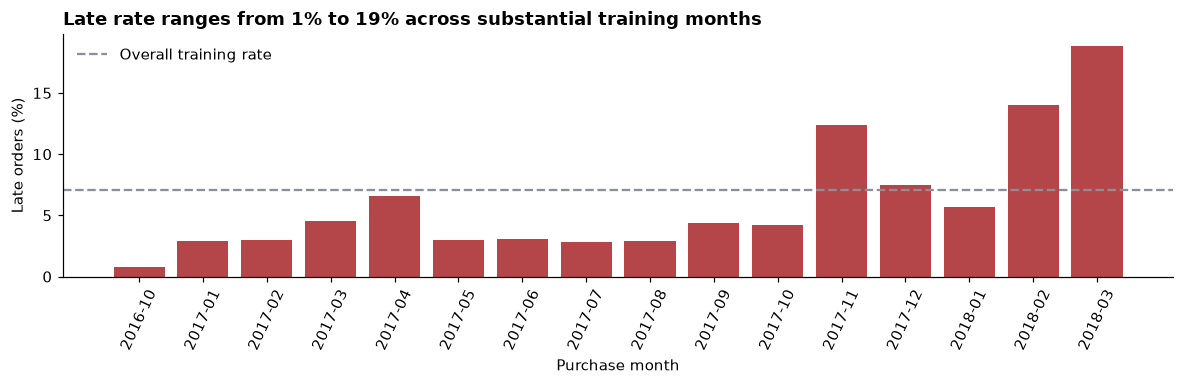

**What we learned.** Of the 75,099 training orders, 7.1% are late. Through 2018-03, across months with at least 265 orders, the rate moves from 0.8% to 18.9%. A fixed alert cutoff may therefore behave differently at different times. More recent training months are omitted from this chart because deliveries still in transit at the cutoff could make their observed late rate misleading.

In [11]:
def monthly_late_rate(train, spec):
    month = train["order_purchase_timestamp"].dt.to_period("M").astype(str)
    return (train.groupby(month)[spec["classification_target"]].agg(orders="size", late_orders="sum", late_rate="mean")
            .reset_index(names="purchase_month"))

months = monthly_late_rate(train, spec)
train_rate = months["late_orders"].sum() / months["orders"].sum()
last_validation_month = pd.to_datetime(folds_view["validation_end"].max()).strftime("%Y-%m")
shown = months.loc[(months["orders"] >= 100) & (months["purchase_month"] <= last_validation_month)].copy()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(shown["purchase_month"], shown["late_rate"] * 100, color=LATE)
ax.axhline(train_rate * 100, color=BASE, ls="--", label="Overall training rate")
ax.set_ylabel("Late orders (%)"); ax.set_xlabel("Purchase month")
ax.tick_params(axis="x", rotation=65); ax.legend(frameon=False)
ax.set_title(f"Late rate ranges from {shown['late_rate'].min():.0%} to {shown['late_rate'].max():.0%} across substantial training months", loc="left")
plt.tight_layout(); plt.show()
display(Markdown(f"**What we learned.** Of the {months['orders'].sum():,} training orders, {train_rate:.1%} are late. Through {last_validation_month}, across months with at least {shown['orders'].min():,} orders, the rate moves from {shown['late_rate'].min():.1%} to {shown['late_rate'].max():.1%}. A fixed alert cutoff may therefore behave differently at different times. More recent training months are omitted from this chart because deliveries still in transit at the cutoff could make their observed late rate misleading."))

The background late rate moves substantially between months. A single fixed rate is therefore an incomplete description of every period, and a cutoff chosen in one period may behave differently in another. The chart supports checking several later periods; it does **not** establish that calendar month should be an input to the model.


## 5. Prepare inputs without looking ahead

Some numeric entries are missing, and models need categories turned into numbers. A **pipeline** keeps each preparation step with the model. In every validation check, it learns how to fill missing values and encode categories from that check's **earlier training orders**, then applies those learned rules to the later orders. Logistic regression also scales numbers and represents purchase hour as a 24-hour cycle. The next cell names the input sets used in the feature comparison.


In [12]:
def hour_components(values):
    hours = np.asarray(values, dtype=float).reshape(-1)
    angle = hours * 2 * np.pi / 24
    return np.column_stack([np.sin(angle), np.cos(angle)])

def hour_names(transformer, input_names):
    return np.array(["hour_sin", "hour_cos"])

def feature_columns(spec, include_payment=True, feature_set=None):
    """Numeric and categorical inputs; `feature_set` ({"numeric", "categorical"}) overrides the saved contract."""
    numeric = feature_set["numeric"] if feature_set else spec["numeric_features"]
    categorical = feature_set["categorical"] if feature_set else spec["categorical_features"]
    omitted = set() if include_payment else set(spec["payment_sensitivity_features"])
    return [c for c in numeric if c not in omitted], [c for c in categorical if c not in omitted]

def feature_stages(spec):
    """Cumulative feature sets for the ladder. The last one is the saved contract."""
    history = spec["history_features"]["features"]
    route = ["route_typical_days", "promise_slack"]
    numeric = spec["numeric_features"]
    retired = list(spec["retired_features"])
    base = [c for c in numeric if c not in history]
    return {
        "original": {"numeric": base, "categorical": spec["categorical_features"] + retired},
        "no_month": {"numeric": base, "categorical": spec["categorical_features"]},
        "route": {"numeric": [c for c in numeric if c in base or c in route],
                  "categorical": spec["categorical_features"]},
        "seller": {"numeric": numeric, "categorical": spec["categorical_features"]},
    }

stages = feature_stages(spec)
log_candidates = tuple(spec["linear_log_candidates"])
print("Feature stages:", {name: len(s["numeric"])+len(s["categorical"]) for name,s in stages.items()})
print("Log-transform candidates:", log_candidates)

Feature stages: {'original': 18, 'no_month': 17, 'route': 19, 'seller': 20}
Log-transform candidates: ('total_price', 'total_freight', 'distance_km', 'total_weight_g', 'total_volume_cm3')


The printed counts give us the modelling path: the original input set included month; we remove it, add route history, then add seller history. The five named numeric inputs are candidates for a log transform in logistic regression. These sets define the comparison in Section 8; we have not measured their value yet.


The next cell puts those preparation rules inside a visible scikit-learn pipeline. Look for three branches: hour, other numbers and categories. A separate log branch is added when that option is tested. The final pipeline step is the estimator. Because preparation stays inside the pipeline, each validation fit learns it from its own training period.


In [13]:
def make_pipeline(family, params, spec, include_payment=True, feature_set=None, log_features=()):
    """Model Pipeline. `log_features` are log1p-transformed before scaling, for the linear family only."""
    numeric, categorical = feature_columns(spec, include_payment, feature_set)
    seed = spec["random_state"]
    branches = []
    logged = []
    if family == "linear":
        logged = [c for c in numeric if c in set(log_features)]
        numeric = [c for c in numeric if c != "purchase_hour" and c not in logged]
        branches.append(("hour", FunctionTransformer(hour_components, feature_names_out=hour_names),
                         ["purchase_hour"]))
    numeric_steps = [("impute", SimpleImputer(strategy="median", keep_empty_features=True))]
    if family == "linear":
        numeric_steps.append(("scale", StandardScaler()))
    branches.append(("numeric", Pipeline(numeric_steps), numeric))
    if logged:
        branches.append(("logged", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]), logged))
    branches.append(("category", OneHotEncoder(handle_unknown="ignore"), categorical))
    preparation = ColumnTransformer(branches, remainder="drop")
    if family == "dummy":
        model = DummyClassifier(strategy="prior")
    elif family == "linear":
        model = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=seed, **params)
    elif family == "tree":
        model = DecisionTreeClassifier(random_state=seed, **params)
    elif family == "forest":
        model = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=4,
                                       random_state=seed, **params)
    else:
        raise ValueError(f"Unknown model family: {family}")
    return Pipeline([("prepare", preparation), ("model", model)])

example = make_pipeline("linear", {"C": 1.0, "class_weight": None}, spec,
                        feature_set=stages["original"])
display(pd.DataFrame([
    {"Stage": name, "What it does": {"hour": "Turn hour into a daily cycle",
                                      "numeric": "Fill missing numbers, then scale",
                                      "category": "Turn categories into indicator columns"}[name],
     "Inputs": len(columns)}
    for name, _, columns in example.named_steps["prepare"].transformers
]).style.hide(axis="index"))
print("Order: prepare inputs → fit", type(example.named_steps["model"]).__name__)


Stage,What it does,Inputs
hour,Turn hour into a daily cycle,1
numeric,"Fill missing numbers, then scale",11
category,Turn categories into indicator columns,6


Order: prepare inputs → fit LogisticRegression


The example output shows which branch handles each input type, followed by logistic regression. In the later loops, this entire object is fitted afresh for each training period. That is the safeguard: even the median used to fill a missing number comes from older training orders, not the validation period.


## 6. Establish a starting score

The baseline gives every order the late share observed in its training period. It cannot rank orders, so any useful model should beat its ranking score on the same later periods. **PR-AUC** is our main comparison because late orders are uncommon and we care about bringing them near the top. We also calculate ROC-AUC and, for a chosen alert cutoff, precision, recall, F1 and MCC. The next cell defines these calculations.


In [14]:
def metrics(y, probability, threshold=0.5):
    predicted = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y, predicted, labels=[0, 1]).ravel()
    return {
        "average_precision": float(average_precision_score(y, probability)),
        "roc_auc": float(roc_auc_score(y, probability)),
        "precision": float(precision_score(y, predicted, zero_division=0)),
        "recall": float(recall_score(y, predicted, zero_division=0)),
        "f1": float(f1_score(y, predicted, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, predicted)),
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp),
    }

def mcc_threshold(y, probability):
    """Maximise MCC over distinct score boundaries; ties favour fewer alerts."""
    y, probability = np.asarray(y, dtype=int), np.asarray(probability, dtype=float)
    if len(y) != len(probability) or len(np.unique(y)) != 2:
        raise ValueError("Threshold selection needs aligned predictions and both classes")
    if not np.isfinite(probability).all() or not np.isin(y, [0, 1]).all():
        raise ValueError("Invalid labels or probabilities")
    order = np.argsort(-probability, kind="stable")
    scores, labels = probability[order], y[order]
    last = np.r_[np.flatnonzero(scores[:-1] != scores[1:]), len(scores) - 1]
    tp = np.cumsum(labels, dtype=float)[last]
    fp = last + 1 - tp
    fn = labels.sum() - tp
    tn = len(labels) - labels.sum() - fp
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = np.divide(tp * tn - fp * fn, denominator, out=np.zeros_like(tp), where=denominator != 0)
    # Include the always-negative option, including when all probabilities equal 1.
    choices = np.r_[np.nextafter(scores[0], np.inf), scores[last]]
    return float(choices[np.argmax(np.r_[0.0, mcc])])

With the score functions defined, we now define the repeated fitting loop. For each candidate and each validation period, it fits a **fresh pipeline** on older resolved orders, scores the later orders and saves the predicted risks. The loop is the same for the baseline, logistic regression, trees and forests.


In [15]:
def evaluate_candidate(train, spec, folds, name, family, params, include_payment=True,
                       feature_set=None, log_features=(), stage="final_grid", feature_set_name="final"):
    rows, predictions = [], []
    numeric, categorical = feature_columns(spec, include_payment, feature_set)
    X, y = train[numeric + categorical], train[spec["classification_target"]]
    started = time.monotonic()
    for fold, (fit, valid) in enumerate(folds):
        pipeline = make_pipeline(family, params, spec, include_payment, feature_set, log_features)
        with threadpool_limits(limits=1):
            pipeline.fit(X.iloc[fit], y.iloc[fit])
            probability = pipeline.predict_proba(X.iloc[valid])[:, 1]
        rows.append({"candidate": name, "algorithm": family, "model_family": MODEL_FAMILIES[family],
                     "stage": stage, "feature_set": feature_set_name,
                     "log_transform": bool(len(log_features)) and family == "linear",
                     "include_payment": include_payment,
                     "fold": fold, "fit_orders": len(fit), "validation_orders": len(valid),
                     "validation_late_rate": float(y.iloc[valid].mean()),
                     **metrics(y.iloc[valid], probability)})
        predictions.append(pd.DataFrame({
            "order_id": train.iloc[valid]["order_id"].to_numpy(),
            "fold": fold, "is_late": y.iloc[valid].to_numpy(), "probability": probability,
        }))
    elapsed = time.monotonic() - started
    print(f"[{stage}] {name}: mean validation AP={np.mean([r['average_precision'] for r in rows]):.4f}; {elapsed:.1f}s", flush=True)
    return rows, pd.concat(predictions, ignore_index=True), elapsed

def summarize(rows):
    """Mean fold metrics per candidate, best mean average precision first (ties keep declared order)."""
    return pd.DataFrame(rows).groupby("candidate", sort=False).agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_precision_at_05=("precision", "mean"),
        mean_recall_at_05=("recall", "mean"),
        mean_f1_at_05=("f1", "mean"),
        mean_mcc_at_05=("mcc", "mean"),
    ).sort_values("mean_average_precision", ascending=False, kind="stable")

We run that loop first for the **prior-only baseline**. Each row in the output is one later validation period; the last printed number is the **mean of those five period scores**. This gives us a fair reference before fitting any model that distinguishes one order from another.


In [16]:
all_rows = []
baseline_rows, baseline_predictions, _ = evaluate_candidate(
    train, spec, folds, "prior_baseline", "dummy", {},
    feature_set=stages["original"], stage="original_grid", feature_set_name="original")
all_rows.extend(baseline_rows)
base = np.mean([r["average_precision"] for r in baseline_rows])
display(pd.DataFrame(baseline_rows)[["fold","validation_late_rate","average_precision","roc_auc",
                                     "precision","recall","f1","mcc"]]
        .style.format(precision=3).hide(axis="index"))
print("Baseline mean validation PR-AUC:", round(np.mean([r["average_precision"] for r in baseline_rows]), 4))

[original_grid] prior_baseline: mean validation AP=0.1067; 0.9s


fold,validation_late_rate,average_precision,roc_auc,precision,recall,f1,mcc
0,0.041,0.041,0.500,0.000,0.000,0.000,0.000
1,0.138,0.138,0.500,0.000,0.000,0.000,0.000
2,0.048,0.048,0.500,0.000,0.000,0.000,0.000
3,0.099,0.099,0.500,0.000,0.000,0.000,0.000
4,0.207,0.207,0.500,0.000,0.000,0.000,0.000


Baseline mean validation PR-AUC: 0.1067


As expected, the baseline gives everyone in a period the same score. Its PR-AUC therefore reflects that period's late share rather than useful risk ordering. The candidate models below must improve on this reference **across later periods**, not merely on their training orders.


## 7. Compare the planned model settings

We start with three model families: logistic regression, a decision tree and a random forest. The declared candidates vary how strongly logistic regression is restrained, whether late orders receive extra weight, and how complex the trees may become. A smaller logistic `C` means stronger restraint; tree depth and minimum leaf size limit how specific tree rules can get.

The next cell shows the declared settings, then fits each on the **same five date-ordered checks using the original inputs**. The table's PR-AUC is the **mean of five validation scores**. We carry the strongest logistic and tree-based settings forward to test feature changes. Alert scores at the default 0.5 cutoff are displayed for completeness but do not choose the ranking model.


In [17]:
display(pd.DataFrame([{"candidate": n, "family": f, "settings": str(p)} for n,f,p in CANDIDATES])
        .style.hide(axis="index"))
for name, family, params in CANDIDATES[1:]:
    rows, _, _ = evaluate_candidate(train, spec, folds, name, family, params,
                                    feature_set=stages["original"],
                                    stage="original_grid", feature_set_name="original")
    all_rows.extend(rows)
original = summarize([r for r in all_rows if r["stage"] == "original_grid"])
display(original[["mean_average_precision","mean_roc_auc","mean_precision_at_05",
                  "mean_recall_at_05","mean_f1_at_05","mean_mcc_at_05"]]
        .style.format(precision=3))

candidate,family,settings
prior_baseline,dummy,{}
logistic_baseline,linear,"{'C': 1.0, 'class_weight': None}"
logistic_c01,linear,"{'C': 0.1, 'class_weight': None}"
logistic_c10,linear,"{'C': 10.0, 'class_weight': None}"
logistic_balanced,linear,"{'C': 1.0, 'class_weight': 'balanced'}"
tree_baseline,tree,"{'max_depth': None, 'min_samples_leaf': 1}"
tree_depth6,tree,"{'max_depth': 6, 'min_samples_leaf': 50}"
tree_depth12,tree,"{'max_depth': 12, 'min_samples_leaf': 20}"
tree_balanced,tree,"{'max_depth': 12, 'min_samples_leaf': 20, 'class_weight': 'balanced'}"
forest_baseline,forest,"{'max_depth': None, 'min_samples_leaf': 1}"


[original_grid] logistic_baseline: mean validation AP=0.1698; 1.4s


[original_grid] logistic_c01: mean validation AP=0.1808; 1.3s


[original_grid] logistic_c10: mean validation AP=0.1665; 1.7s


[original_grid] logistic_balanced: mean validation AP=0.1596; 2.6s


...

[original_grid] forest_baseline: mean validation AP=0.1416; 52.4s


[original_grid] forest_depth12: mean validation AP=0.1690; 14.0s


[original_grid] forest_leaf20: mean validation AP=0.1662; 24.3s


[original_grid] forest_balanced: mean validation AP=0.1634; 24.8s


,mean_average_precision,mean_roc_auc,mean_precision_at_05,mean_recall_at_05,mean_f1_at_05,mean_mcc_at_05
candidate,,,,,,
logistic_c01,0.181,0.638,0.000,0.000,0.000,0.000
logistic_baseline,0.170,0.615,0.000,0.000,0.000,-0.002
forest_depth12,0.169,0.632,0.000,0.000,0.000,0.000
logistic_c10,0.167,0.605,0.118,0.003,0.006,0.013
forest_leaf20,0.166,0.628,0.000,0.000,0.000,0.000
forest_balanced,0.163,0.626,0.200,0.053,0.079,0.051
logistic_balanced,0.160,0.600,0.164,0.431,0.182,0.094
forest_baseline,0.142,0.591,0.000,0.000,0.000,0.000
tree_depth12,0.139,0.555,0.125,0.002,0.005,0.008


On the original inputs, the more restrained logistic model leads. An unrestricted single tree is only slightly above the baseline; constraining trees helps, and the best forest gets closer to logistic regression. That is why the next section keeps one leading logistic configuration and one leading tree-based configuration while changing features. These are validation comparisons, not final-test results.


## 8. Which additions earn their place?

We now hold the leading model settings fixed and change **one input decision at a time**: remove month, add route time and promise slack together, add past seller handover time, then try the log transform for logistic regression. This sequence is a *ladder*: each change is compared with the step it builds on, using the same five later validation periods. It can test the route pair together, but cannot separate the individual gain of route time from promise slack.

The next cell declares the ladder steps and the rule for comparing each step with its predecessor. It defines the experiment; it does not fit anything yet.


In [18]:
LADDER_MODEL_STEPS = [
    # (step, line, candidate, compared with)
    (1, "baseline", "prior_baseline", None),
    (2, "linear", "logistic_baseline", "prior_baseline"),
    (3, "linear", "logistic_c01", "logistic_baseline"),
    (4, "linear", "logistic_balanced", "logistic_baseline"),
    (5, "tree_based", "tree_baseline", "prior_baseline"),
    (6, "tree_based", "tree_depth12", "tree_baseline"),
    (7, "tree_based", "forest_baseline", "tree_baseline"),
    (8, "tree_based", "forest_depth12", "forest_baseline"),
]

LADDER_LABELS = {
    "prior_baseline": "Baseline: always predict the training late rate",
    "logistic_baseline": "Logistic regression, default settings",
    "logistic_c01": "Logistic regression, stronger regularisation (C=0.1)",
    "logistic_balanced": "Logistic regression, class-weighted (vs default)",
    "tree_baseline": "Decision tree, default settings",
    "tree_depth12": "Decision tree, constrained (depth 12, leaf 20)",
    "forest_baseline": "Random forest, default settings",
    "forest_depth12": "Random forest, constrained (depth 12, leaf 20)",
}

FEATURE_STEPS = [
    (9, "no_month", "Drop purchase_month", "original"),
    (10, "route", "Add route promise slack and route typical days", "no_month"),
    (11, "seller", "Add seller ship speed", "route"),
    (12, "seller_log", "Log-transform skewed inputs (linear model only)", "seller"),
]

def build_ladder(metric_rows, winners):
    """One row per ladder step and fold, plus a summary comparing each step with the step it builds on."""
    frame = pd.DataFrame(metric_rows)

    def folds_of(stage, candidate):
        part = frame[(frame["stage"] == stage) & (frame["candidate"] == candidate)].sort_values("fold")
        if part.empty:
            raise KeyError((stage, candidate))
        return part

    entries = []
    for step, line, candidate, compare in LADDER_MODEL_STEPS:
        entries.append({"step": step, "line": line, "label": LADDER_LABELS[candidate],
                        "stage": "original_grid", "candidate": candidate,
                        "compare": ("original_grid", compare) if compare else None})
    for line, winner in winners.items():
        previous = ("original_grid", winner)
        for step, feature_stage, label, _ in FEATURE_STEPS:
            if feature_stage == "seller_log" and line != "linear":
                continue
            key = (f"feature_{feature_stage}", f"{winner}@{feature_stage}")
            entries.append({"step": step, "line": line, "label": label, "stage": key[0],
                            "candidate": key[1], "compare": previous})
            previous = key
    per_fold, summary = [], []
    for entry in sorted(entries, key=lambda e: (e["step"], e["line"])):
        part = folds_of(entry["stage"], entry["candidate"])
        ratio = (part["average_precision"] / part["validation_late_rate"]).to_numpy()
        for (_, row), value in zip(part.iterrows(), ratio):
            per_fold.append({"step": entry["step"], "line": entry["line"], "label": entry["label"],
                             "candidate": entry["candidate"], "fold": row["fold"],
                             "validation_late_rate": row["validation_late_rate"],
                             "average_precision": row["average_precision"], "roc_auc": row["roc_auc"],
                             "ap_over_late_rate": value})
        record = {"step": entry["step"], "line": entry["line"], "label": entry["label"],
                  "candidate": entry["candidate"],
                  "mean_average_precision": part["average_precision"].mean(),
                  "mean_roc_auc": part["roc_auc"].mean(),
                  "mean_ap_over_late_rate": ratio.mean()}
        if entry["compare"]:
            other = folds_of(*entry["compare"])
            record.update({
                "compared_with": entry["compare"][1],
                "delta_average_precision": part["average_precision"].mean() - other["average_precision"].mean(),
                "delta_roc_auc": part["roc_auc"].mean() - other["roc_auc"].mean(),
                "folds_improved_ap": int((part["average_precision"].to_numpy()
                                          > other["average_precision"].to_numpy()).sum()),
                "folds_improved_auc": int((part["roc_auc"].to_numpy() > other["roc_auc"].to_numpy()).sum()),
            })
        summary.append(record)
    return pd.DataFrame(per_fold), pd.DataFrame(summary)

Now we fit the chosen logistic and forest settings at each feature stage. The printed scores are **mean PR-AUC across the five later periods**. We keep the log transform for the final logistic comparison only if its validation mean is at least as high as the untransformed version. The following table makes each before/after difference explicit.


In [19]:
winners = {}
for line in ("linear", "tree_based"):
    winners[line] = next(n for n in original.index
                         if next(c for c in CANDIDATES if c[0] == n)[1] != "dummy"
                         and MODEL_FAMILIES[next(c for c in CANDIDATES if c[0] == n)[1]] == line)
candidate = {name: (family, params) for name, family, params in CANDIDATES}
print("Best original settings by family:", winners)
for line, winner in winners.items():
    family, params = candidate[winner]
    for _, set_name, _, _ in FEATURE_STEPS:
        if set_name == "seller_log":
            if family != "linear":
                continue
            name = f"{winner}@seller_log"
            rows, _, _ = evaluate_candidate(train, spec, folds, name, family, params,
                                           feature_set=stages["seller"], log_features=log_candidates,
                                           stage="feature_seller_log", feature_set_name="seller")
        else:
            name = f"{winner}@{set_name}"
            rows, _, _ = evaluate_candidate(train, spec, folds, name, family, params,
                                           feature_set=stages[set_name],
                                           stage=f"feature_{set_name}", feature_set_name=set_name)
        all_rows.extend(rows)
frame = pd.DataFrame(all_rows)
linear_winner = winners["linear"]
with_log = frame.loc[frame.candidate.eq(f"{linear_winner}@seller_log"), "average_precision"].mean()
without_log = frame.loc[frame.candidate.eq(f"{linear_winner}@seller"), "average_precision"].mean()
final_log = log_candidates if with_log >= without_log else ()
print(f"Log transform: with {with_log:.4f}, without {without_log:.4f}; adopted={bool(final_log)}")
ladder_detail, ladder_summary = build_ladder(
    [r for r in all_rows if r["stage"] != "final_grid"], winners)
ladder = ladder_summary

Best original settings by family: {'linear': 'logistic_c01', 'tree_based': 'forest_depth12'}


[feature_no_month] logistic_c01@no_month: mean validation AP=0.1897; 1.2s


[feature_route] logistic_c01@route: mean validation AP=0.1910; 1.3s


[feature_seller] logistic_c01@seller: mean validation AP=0.1954; 1.3s


[feature_seller_log] logistic_c01@seller_log: mean validation AP=0.2003; 1.4s


[feature_no_month] forest_depth12@no_month: mean validation AP=0.1864; 12.9s


[feature_route] forest_depth12@route: mean validation AP=0.1972; 17.4s


[feature_seller] forest_depth12@seller: mean validation AP=0.1999; 18.7s


Log transform: with 0.2003, without 0.1954; adopted=True


The run kept the log transform because the transformed logistic model scored higher on validation. That is the answer the distribution picture could not give us. The next display places all model and feature steps side by side; read the “change” column against the named previous step, not necessarily the row immediately above.


The ladder table shows both **how much average PR-AUC changed** and **how many of the five periods improved**. The chart below it follows the main logistic and forest paths; step numbers are keyed to the table. Look especially at the changes after month is removed and route and seller history are added. A few thousandths of PR-AUC are too small to treat as a decisive win.


Step / line,What changed,PR-AUC,Change vs named prior,ROC-AUC,PR-AUC ÷ late rate,Windows better
1 · baseline,Baseline: always predict the training late rate,0.107,—,0.500,1.00×,—
2 · linear,Logistic: default settings,0.170,+0.063,0.615,1.58×,5/5
3 · linear,Logistic: stronger regularisation (C=0.1),0.181,+0.011,0.638,1.68×,5/5
4 · linear,Logistic: class-weighted (vs default),0.160,-0.010,0.600,1.49×,0/5
5 · tree,"Decision tree, default settings",0.109,+0.002,0.508,1.02×,5/5
6 · tree,"Decision tree, constrained (depth 12, leaf 20)",0.139,+0.030,0.555,1.29×,5/5
7 · tree,"Random forest, default settings",0.142,+0.033,0.591,1.33×,5/5
8 · tree,"Random forest, constrained (depth 12, leaf 20)",0.169,+0.027,0.632,1.58×,5/5
9 · linear,Drop purchase_month,0.190,+0.009,0.656,1.74×,3/5
9 · tree,Drop purchase_month,0.186,+0.017,0.647,1.70×,5/5


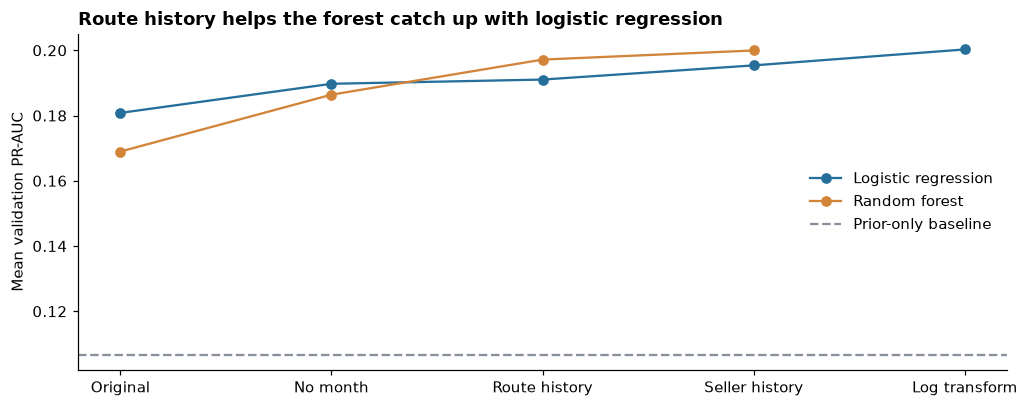

In [20]:
ladder_view = ladder.copy()
ladder_view["step_name"] = ladder_view["step"].astype(str) + " · " + ladder_view["line"].replace({"tree_based":"tree", "linear":"linear"})
ladder_view["change"] = ladder_view["label"].str.replace("Logistic regression, ", "Logistic: ", regex=False)
ladder_view["delta"] = ladder_view["delta_average_precision"].map(lambda x: "—" if pd.isna(x) else f"{x:+.3f}")
ladder_view["windows"] = ladder_view["folds_improved_ap"].map(lambda x: "—" if pd.isna(x) else f"{int(x)}/{len(folds)}")
display(ladder_view[["step_name","change","mean_average_precision","delta","mean_roc_auc","mean_ap_over_late_rate","windows"]].rename(columns={
    "step_name":"Step / line", "change":"What changed", "mean_average_precision":"PR-AUC", "delta":"Change vs named prior",
    "mean_roc_auc":"ROC-AUC", "mean_ap_over_late_rate":"PR-AUC ÷ late rate", "windows":"Windows better"})
    .style.format({"PR-AUC":"{:.3f}","ROC-AUC":"{:.3f}","PR-AUC ÷ late rate":"{:.2f}×"}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(9.5, 3.8))
plot_paths = [
    ("linear", LINEAR, "Logistic regression", [3, 9, 10, 11, 12]),
    ("tree_based", FOREST, "Random forest", [8, 9, 10, 11]),
]
for line, color, name, path in plot_paths:
    scores = [ladder.loc[ladder.line.eq(line) & ladder.step.eq(step),
                         "mean_average_precision"].iloc[0] for step in path]
    ax.plot(range(len(path)), scores, "o-", color=color, label=name)
ax.axhline(base, color=BASE, ls="--", label="Prior-only baseline")
ax.set_xticks(range(5), ["Original", "No month", "Route history", "Seller history", "Log transform"])
ax.set_ylabel("Mean validation PR-AUC")
ax.legend(frameon=False)
ax.set_title("Route history helps the forest catch up with logistic regression", loc="left")
plt.tight_layout(); plt.show()


The forest starts behind logistic regression but catches up as the new history features enter. The table is the precise record: it includes side experiments the chart omits and shows whether a gain repeats across periods. The next short calculation pulls out the changes most relevant to our feature choices.


In [21]:
def ladder_row(step, line): return ladder.loc[ladder.step.eq(step) & ladder.line.eq(line)].iloc[0]
s2, s3, s4 = [ladder_row(s,"linear") for s in [2,3,4]]
s5, s6, s7, s8 = [ladder_row(s,"tree_based") for s in [5,6,7,8]]
l9, t9 = ladder_row(9,"linear"), ladder_row(9,"tree_based")
l10, t10 = ladder_row(10,"linear"), ladder_row(10,"tree_based")
l11, t11 = ladder_row(11,"linear"), ladder_row(11,"tree_based")
l12 = ladder_row(12,"linear")
display(Markdown(f"""**What this shows.** Logistic regression starts **{s2.delta_average_precision:+.3f}** mean PR-AUC above the simple baseline. Stronger restraint adds **{s3.delta_average_precision:+.3f}**. Giving late orders extra weight instead lowers the score by **{abs(s4.delta_average_precision):.3f}** and helps in **{int(s4.folds_improved_ap)} of {len(folds)}** periods. A single tree starts near the baseline. Limiting its size helps, and the constrained forest gains **{s8.delta_average_precision:+.3f}** over the default forest.

Removing purchase month raises logistic regression by **{l9.delta_average_precision:+.3f}** mean PR-AUC (**{int(l9.folds_improved_ap)} of {len(folds)}** periods improve) and the forest by **{t9.delta_average_precision:+.3f}** (**{int(t9.folds_improved_ap)} of {len(folds)}** improve). The route features add **{l10.delta_average_precision:+.3f}** for logistic regression and **{t10.delta_average_precision:+.3f}** for the forest. Earlier seller handovers add **{l11.delta_average_precision:+.3f}** and **{t11.delta_average_precision:+.3f}**, respectively; the forest's seller gain is small. Compressing large numbers adds **{l12.delta_average_precision:+.3f}** for logistic regression. All these values are averages of the five validation scores, used to choose what to test later."""))


**What this shows.** Logistic regression starts **+0.063** mean PR-AUC above the simple baseline. Stronger restraint adds **+0.011**. Giving late orders extra weight instead lowers the score by **0.010** and helps in **0 of 5** periods. A single tree starts near the baseline. Limiting its size helps, and the constrained forest gains **+0.027** over the default forest.

Removing purchase month raises logistic regression by **+0.009** mean PR-AUC (**3 of 5** periods improve) and the forest by **+0.017** (**5 of 5** improve). The route features add **+0.001** for logistic regression and **+0.011** for the forest. Earlier seller handovers add **+0.004** and **+0.003**, respectively; the forest's seller gain is small. Compressing large numbers adds **+0.005** for logistic regression. All these values are averages of the five validation scores, used to choose what to test later.

The clearest feature decision here is **to leave month out**: both model families improve on average, especially the forest. Route history helps the forest markedly; seller history adds a smaller gain, and the log transform helps logistic regression. The small differences remain uncertain because these same validation periods guided our choices. The reserved test has not been opened.


## 9. Compare all candidates with the chosen inputs

Feature changes can alter which settings work best, so we rerun **all declared candidates** on the chosen feature set. Logistic regression uses the log transform because it improved its earlier validation comparison. The next table again averages scores from the same five date-ordered periods. We select by mean PR-AUC, while treating a tiny gap as a practical tie.


In [22]:
predictions_by_candidate = {}
final_elapsed = {}
for name, family, params in CANDIDATES:
    rows, oof_candidate, elapsed = evaluate_candidate(
        train, spec, folds, name, family, params, feature_set=stages["seller"],
        log_features=final_log, stage="final_grid", feature_set_name="seller")
    all_rows.extend(rows)
    predictions_by_candidate[name] = oof_candidate
    final_elapsed[name] = elapsed
final_rows = [r for r in all_rows if r["stage"] == "final_grid"]
final_summary = summarize(final_rows)
selected = final_summary.index[0]
chosen = final_summary.loc[selected, "mean_average_precision"]
forest_ap = final_summary.loc["forest_depth12", "mean_average_precision"]
family_winners = {line: next(n for n in final_summary.index if MODEL_FAMILIES[candidate[n][0]] == line)
                  for line in ("linear", "tree_based")}
oof = predictions_by_candidate[selected]
cv = pd.DataFrame(all_rows)
summary = final_summary.reset_index().rename(columns={"index":"candidate"})
print("Provisional highest-mean candidate:", selected)
print("Family winners:", family_winners)
display(final_summary[["mean_average_precision","std_average_precision","mean_roc_auc",
                       "mean_precision_at_05","mean_recall_at_05","mean_f1_at_05","mean_mcc_at_05"]]
        .style.format(precision=3))

[final_grid] prior_baseline: mean validation AP=0.1067; 0.8s


[final_grid] logistic_baseline: mean validation AP=0.1913; 1.6s


[final_grid] logistic_c01: mean validation AP=0.2003; 1.4s


[final_grid] logistic_c10: mean validation AP=0.1884; 1.5s


[final_grid] logistic_balanced: mean validation AP=0.1872; 2.9s


...

[final_grid] forest_depth12: mean validation AP=0.1999; 33.5s


[final_grid] forest_leaf20: mean validation AP=0.1985; 48.3s


[final_grid] forest_balanced: mean validation AP=0.1967; 43.1s


Provisional highest-mean candidate: logistic_c01
Family winners: {'linear': 'logistic_c01', 'tree_based': 'forest_depth12'}


,mean_average_precision,std_average_precision,mean_roc_auc,mean_precision_at_05,mean_recall_at_05,mean_f1_at_05,mean_mcc_at_05
candidate,,,,,,,
logistic_c01,0.200,0.133,0.677,0.000,0.000,0.000,-0.001
forest_depth12,0.200,0.142,0.668,0.000,0.000,0.000,0.000
forest_leaf20,0.198,0.140,0.664,0.000,0.000,0.000,0.000
forest_balanced,0.197,0.134,0.669,0.236,0.198,0.198,0.135
logistic_baseline,0.191,0.127,0.664,0.000,0.000,0.000,-0.001
logistic_c10,0.188,0.127,0.658,0.000,0.000,0.000,-0.001
logistic_balanced,0.187,0.124,0.657,0.167,0.507,0.241,0.135
forest_baseline,0.181,0.133,0.635,0.000,0.000,0.000,-0.002
tree_depth6,0.149,0.092,0.566,0.000,0.000,0.000,0.000


Logistic regression has the highest mean PR-AUC, but the leading forest is effectively tied. We provisionally select logistic regression under the stated highest-mean rule; both remain candidates for a later voting-ensemble check. The table's precision, recall, F1 and MCC use the **default 0.5 cutoff** and do not decide which model ranks orders best.


An average can hide a model that fails in one period. This plot puts the selected model and the prior-only baseline on **each of the five validation periods**. Each point is one period's PR-AUC. Look for whether the selected model stays above the baseline and whether the gap is steady.


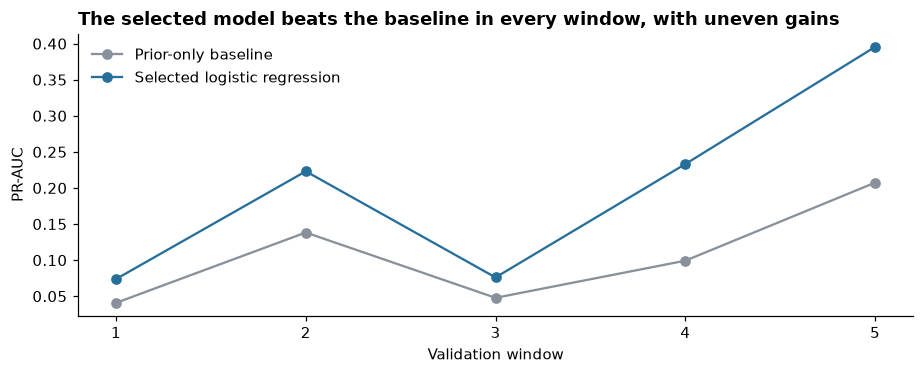

In [23]:
final_cv = cv[cv.stage.eq("final_grid")]
subset = final_cv[final_cv.candidate.isin([selected, "prior_baseline"])]
fig, ax = plt.subplots(figsize=(8.5,3.5))
for model_name,color,label in [("prior_baseline",BASE,"Prior-only baseline"),
                              (selected,LINEAR,"Selected logistic regression")]:
    d = subset[subset.candidate.eq(model_name)].sort_values("fold")
    ax.plot(d.fold+1, d.average_precision, "o-", color=color, label=label)
ax.set_xticks(folds_view.fold+1); ax.set_xlabel("Validation window")
ax.set_ylabel("PR-AUC"); ax.legend(frameon=False)
ax.set_title("The selected model beats the baseline in every window, with uneven gains", loc="left")
plt.tight_layout(); plt.show()

The selected model beats the baseline in **every period**, so the average gain does not come from just one lucky window. The size of that gain still varies. We should expect the model's usefulness to change when the mix of orders or the late rate changes.


### Does the payment assumption matter?

The source does not timestamp exactly when payment method and instalments became available. We therefore refit the leading models **without those two inputs** on the same validation periods. The table compares mean PR-AUC with and without payment for each model family. This checks how much our results *depend* on payment; it cannot prove when the fields were recorded.


In [24]:
sensitivity = []
for algorithm in ("linear", "tree", "forest"):
    best = next(n for n in final_summary.index if candidate[n][0] == algorithm)
    family, params = candidate[best]
    name = best + "_no_payment"
    rows, _, _ = evaluate_candidate(train, spec, folds, name, family, params,
                                    include_payment=False, feature_set=stages["seller"],
                                    log_features=final_log, stage="payment_check", feature_set_name="seller")
    all_rows.extend(rows)
    with_ap = final_summary.loc[best, "mean_average_precision"]
    without_ap = pd.DataFrame(rows)["average_precision"].mean()
    sensitivity.append({"algorithm": algorithm, "with_payment_candidate": best,
                        "with_payment_ap": with_ap, "without_payment_ap": without_ap,
                        "delta_without_minus_with": without_ap - with_ap})
payments = pd.DataFrame(sensitivity)

payment_view = payments.copy()
payment_view["model"] = payment_view.algorithm.map({"linear":"Logistic", "tree":"Decision tree", "forest":"Random forest"})
display(payment_view[["model","with_payment_ap","without_payment_ap","delta_without_minus_with"]].rename(columns={
    "model":"Model", "with_payment_ap":"With payment", "without_payment_ap":"Without payment",
    "delta_without_minus_with":"Without − with"}).style.format(precision=4).hide(axis="index"))
display(Markdown(f"**What this shows.** Removing the payment inputs changes average PR-AUC by at most "
                 f"**{payments.delta_without_minus_with.abs().max():.4f}** across the paired checks. "
                 "The models do not depend much on these inputs. We still cannot confirm exactly when the payment information became available."))


[payment_check] logistic_c01_no_payment: mean validation AP=0.2001; 2.0s


[payment_check] tree_depth6_no_payment: mean validation AP=0.1499; 2.2s


[payment_check] forest_depth12_no_payment: mean validation AP=0.1995; 16.2s


Model,With payment,Without payment,Without − with
Logistic,0.2003,0.2001,-0.0002
Decision tree,0.1495,0.1499,0.0004
Random forest,0.1999,0.1995,-0.0005


**What this shows.** Removing the payment inputs changes average PR-AUC by at most **0.0005** across the paired checks. The models do not depend much on these inputs. We still cannot confirm exactly when the payment information became available.

### What if we mix dates?

Many projects randomly mix early and late orders before splitting them. That can make evaluation easier than predicting a genuinely later period. As a secondary check, the next cell makes five shuffled, class-balanced folds **inside the primary training period only** and compares their mean scores with our date-ordered checks. The reserved test remains untouched. This tells us how sensitive the reported score is to the testing method; the date-ordered result still guides model choice.


In [25]:
eligible = np.flatnonzero(train[spec["primary_fold"]].ge(0).to_numpy())
labels = train[spec["classification_target"]].to_numpy()
shuffled = [(eligible[fit], eligible[valid]) for fit, valid in
            StratifiedKFold(spec["n_folds"], shuffle=True, random_state=spec["random_state"])
            .split(eligible, labels[eligible])]
random_rows = []
for line in ("linear", "tree_based"):
    name = family_winners[line]
    family, params = candidate[name]
    rows, _, _ = evaluate_candidate(train, spec, shuffled, name, family, params,
                                    feature_set=stages["seller"], log_features=final_log,
                                    stage="random_split_check", feature_set_name="seller")
    random_rows.extend(rows)
    all_rows.extend(rows)
split_rows = pd.DataFrame([r for r in all_rows if r["stage"] in ("final_grid","random_split_check")
                           and r["candidate"] in family_winners.values()])
split_rows["split"] = np.where(split_rows["stage"].eq("final_grid"), "time_based", "random")
split_rows["ap_over_late_rate"] = split_rows["average_precision"] / split_rows["validation_late_rate"]
splits = split_rows.groupby(["candidate", "model_family", "split"], sort=False).agg(
    mean_average_precision=("average_precision", "mean"), mean_roc_auc=("roc_auc", "mean"),
    mean_ap_over_late_rate=("ap_over_late_rate", "mean")).reset_index()

comparison = splits.pivot(index="candidate", columns="split", values=["mean_average_precision", "mean_roc_auc"])
comparison.columns = [f"{metric}_{split}" for metric, split in comparison.columns]
comparison = comparison.reset_index()
comparison["model"] = comparison["candidate"].map({"logistic_c01":"Logistic regression", "forest_depth12":"Random forest"})
display(comparison[["model", "mean_average_precision_time_based", "mean_average_precision_random", "mean_roc_auc_time_based", "mean_roc_auc_random"]].rename(columns={
    "model":"Model", "mean_average_precision_time_based":"PR-AUC: time", "mean_average_precision_random":"PR-AUC: random",
    "mean_roc_auc_time_based":"ROC-AUC: time", "mean_roc_auc_random":"ROC-AUC: random"}).style.format(precision=3).hide(axis="index"))

[random_split_check] logistic_c01: mean validation AP=0.3030; 3.0s


[random_split_check] forest_depth12: mean validation AP=0.3270; 19.0s


Model,PR-AUC: time,PR-AUC: random,ROC-AUC: time,ROC-AUC: random
Random forest,0.200,0.327,0.668,0.767
Logistic regression,0.200,0.303,0.677,0.758


Both leading models look stronger when dates are mixed. The next line gives the exact logistic-regression comparison. Each number is the **mean of five validation scores** under that split method; the random and time-ordered checks answer different questions, so we do not substitute one for the other.


In [26]:
linear_cmp = comparison.loc[comparison.candidate.eq("logistic_c01")].iloc[0]
display(Markdown(f"**What this shows.** Logistic regression scores **{linear_cmp['mean_average_precision_random']:.3f}** "
                 f"average PR-AUC when dates are mixed, versus **{linear_cmp['mean_average_precision_time_based']:.3f}** "
                 "when each check predicts later orders. The date-ordered result answers our main question, so it guides model choice. "
                 "Each score is the average of five separate checks."))


**What this shows.** Logistic regression scores **0.303** average PR-AUC when dates are mixed, versus **0.200** when each check predicts later orders. The date-ordered result answers our main question, so it guides model choice. Each score is the average of five separate checks.

### Did the forest catch up?

The ladder suggests that route and seller history narrowed the forest's early gap with logistic regression. The next calculation compares the gaps **before and after** those features, using the same validation metric. It describes what happened; it cannot prove why the forest improved.


In [27]:
first_gap = s3.mean_average_precision - s8.mean_average_precision
last_gap = chosen - forest_ap
random_forest = splits.query('candidate == "forest_depth12" and split == "random"').iloc[0]
random_linear = splits.query('candidate == "logistic_c01" and split == "random"').iloc[0]
display(Markdown(f"**What this shows.** With the original inputs, logistic regression led the forest by "
                 f"**{first_gap:.3f}** average PR-AUC. With the final inputs, the gap is only **{last_gap:.4f}**: "
                 "too small to call a clear win. In the shuffled check, the forest scores "
                 f"**{random_forest.mean_average_precision:.3f}** versus **{random_linear.mean_average_precision:.3f}** "
                 "for logistic regression. We can later test whether combining their rankings helps."))


**What this shows.** With the original inputs, logistic regression led the forest by **0.012** average PR-AUC. With the final inputs, the gap is only **0.0003**: too small to call a clear win. In the shuffled check, the forest scores **0.327** versus **0.303** for logistic regression. We can later test whether combining their rankings helps.

The final gap is too small to establish that logistic regression truly outperforms the forest. A later voting comparison can test whether combining their scores adds anything. Mixing dates gave higher scores to both but does not change our date-ordered selection rule.


## 10. What are the fitted models using?

The validation scores tell us *how well* the models rank orders. We now inspect *which inputs the fitted models rely on*, while avoiding a causal interpretation. This is especially important because promise length, usual route time and promise slack carry overlapping information.


For logistic regression, we show **odds ratios** from the five training fits. A value below one means the fitted model associates an increase in that input with lower late odds; above one means higher odds. For numeric inputs, the increase is one standard deviation after preparation. The range across fits shows how stable that fitted association is.

For the forest, we shuffle one input in a validation period and see how much PR-AUC falls. A bigger fall means the forest relied more on that input *in that period*. If two inputs carry similar information, each may receive less individual credit. Neither chart tells us what causes a delay. The next cell calculates both summaries.


In [28]:
def logistic_odds_ratios(train, spec, folds, params, feature_set, log_features):
    """Standardised coefficients and odds ratios of the linear model, refitted on each validation fold's training rows."""
    numeric, categorical = feature_columns(spec, True, feature_set)
    X, y = train[numeric + categorical], train[spec["classification_target"]]
    rows = []
    for fold, (fit, _) in enumerate(folds):
        pipeline = make_pipeline("linear", params, spec, True, feature_set, log_features)
        with threadpool_limits(limits=1):
            pipeline.fit(X.iloc[fit], y.iloc[fit])
        names = pipeline.named_steps["prepare"].get_feature_names_out()
        coefficients = pipeline.named_steps["model"].coef_[0]
        rows.extend({"fold": fold, "feature": name, "coefficient": float(c), "odds_ratio": float(np.exp(c))}
                    for name, c in zip(names, coefficients))
    return pd.DataFrame(rows)

def forest_permutation_importance(train, spec, folds, family, params, feature_set, repeats=5):
    """How much validation PR-AUC falls when one input is shuffled, per fold."""
    numeric, categorical = feature_columns(spec, True, feature_set)
    X, y = train[numeric + categorical], train[spec["classification_target"]]
    rows = []
    for fold, (fit, valid) in enumerate(folds):
        pipeline = make_pipeline(family, params, spec, True, feature_set)
        pipeline.fit(X.iloc[fit], y.iloc[fit])
        result = permutation_importance(pipeline, X.iloc[valid], y.iloc[valid], scoring="average_precision",
                                        n_repeats=repeats, random_state=spec["random_state"], n_jobs=1)
        rows.extend({"fold": fold, "feature": feature, "importance_mean": float(m), "importance_std": float(sd)}
                    for feature, m, sd in zip(X.columns, result.importances_mean, result.importances_std))
    return pd.DataFrame(rows)

linear_name, tree_name = family_winners["linear"], family_winners["tree_based"]
odds = logistic_odds_ratios(train, spec, folds, candidate[linear_name][1],
                            stages["seller"], final_log)
importance = forest_permutation_importance(train, spec, folds, candidate[tree_name][0],
                                           candidate[tree_name][1], stages["seller"])
print(f"Odds-ratio rows: {len(odds):,}; forest importance rows: {len(importance):,}")

Odds-ratio rows: 736; forest importance rows: 100


The counts confirm that both interpretation summaries cover the five validation checks. We plot a short list of numeric logistic effects and the forest inputs whose shuffling has the largest effect. These are descriptions of the fitted models, not new model-selection scores.


Start with two rows in the logistic chart: **past seller handover time** sits right of one, so slower historical handovers go with higher fitted late odds; **days promised** sits left of one, so a longer promise goes with lower fitted odds. The vertical line at one means no fitted change. Each dot is the middle estimate across five training fits, and the whisker is their range. We interpret the route and slack rows together because their inputs overlap by construction.


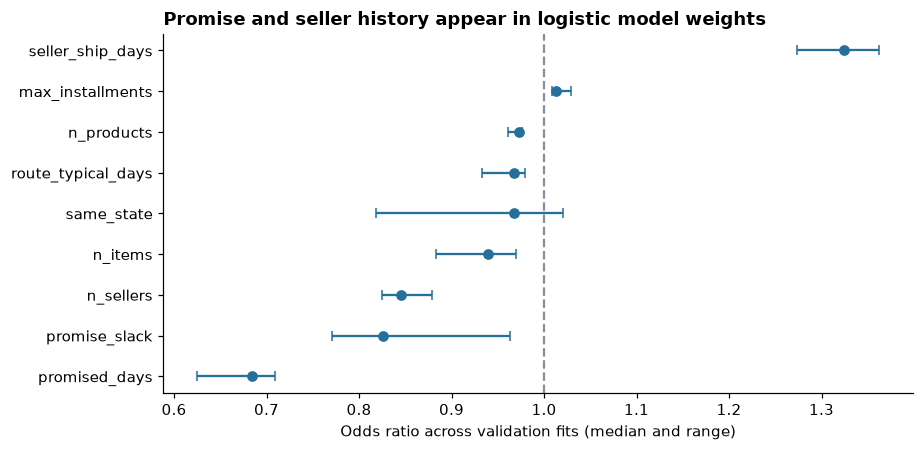

In [29]:
numeric = odds[odds.feature.str.startswith("numeric__")].copy()
numeric["feature"] = numeric.feature.str.removeprefix("numeric__")
ors = numeric.groupby("feature").odds_ratio.agg(["median","min","max"])
ors["strength"] = np.abs(np.log(ors["median"]))
ors = ors.sort_values("strength", ascending=False).head(9).sort_values("median")
fig, ax = plt.subplots(figsize=(8.5,4.2))
y = np.arange(len(ors))
ax.errorbar(ors["median"],y,xerr=[ors["median"]-ors["min"],ors["max"]-ors["median"]],fmt="o",color=LINEAR,capsize=3)
ax.axvline(1,color=BASE,ls="--");ax.set_yticks(y,ors.index)
ax.set_xlabel("Odds ratio across validation fits (median and range)")
ax.set_title("Promise and seller history appear in logistic model weights",loc="left")
plt.tight_layout();plt.show()


The logistic chart shows fitted **associations**, not isolated effects. The promise, route-time and slack inputs are linked by the slack calculation, so the model can spread their shared information across coefficients. In particular, do not read the route-time dot alone as a claim that slower routes prevent lateness. The next chart asks a different question of the forest: how much does its validation ranking worsen when we scramble one input?


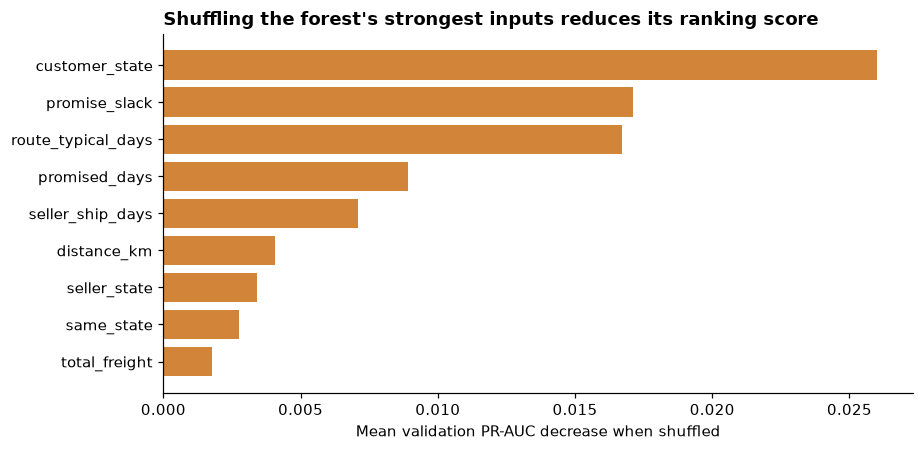

In [30]:
imp = importance.groupby("feature").importance_mean.agg(["mean","min","max"])
imp["strength"] = imp["mean"].abs();imp = imp.sort_values("strength",ascending=False).head(9).sort_values("mean")
fig,ax=plt.subplots(figsize=(8.5,4.2))
y=np.arange(len(imp));ax.barh(y,imp["mean"],color=FOREST)
ax.set_yticks(y,imp.index);ax.axvline(0,color=BASE,lw=1)
ax.set_xlabel("Mean validation PR-AUC decrease when shuffled")
ax.set_title("Shuffling the forest's strongest inputs reduces its ranking score",loc="left")
plt.tight_layout();plt.show()


Promise-related and route/seller-history inputs appear prominently, and the forest also relies on customer state. But **promise slack = promised days − usual route time**: those three inputs overlap by construction. Their separate odds ratios or shuffle bars cannot be read as each feature's independent effect. A negative route-time coefficient beside a negative promise-slack coefficient, for example, is not evidence that slower routes prevent lateness. These plots describe how the fitted models divide credit; they do not identify causes.


## 11. From risk scores to a review list

Suppose a team can investigate only some orders. Would looking at those the model ranks highest find more late deliveries than choosing at random? We examine **two possible operating rules**.

First, we choose a provisional yes/no cutoff that maximises **MCC** on the pooled validation predictions, then compare its alerts with the default 0.5 cutoff. Second, we shortlist the highest-risk share *within each validation period*, as a team with limited capacity might. The cutoff's alert scores are optimistic because the same validation predictions choose and describe it; they are not a final operational promise.


In [31]:
def _ranking_rates(counts):
    precision = counts["caught"] / counts["flagged"]
    return {"recall": counts["caught"] / counts["late"], "precision": precision,
            "lift": precision / (counts["late"] / counts["orders"])}

def risk_ranking(predictions, shares=(0.1, 0.2, 0.3)):
    """Review the riskiest `share` of orders within each validation period.

    Recall is the share of late orders in the flagged set; lift is how many times more often a flagged order is late
    than a typical order in that period. Random flagging would give recall equal to the share and lift of 1.
    """
    rows = []
    for share in shares:
        totals = {"flagged": 0, "caught": 0, "late": 0, "orders": 0}
        for fold, group in predictions.groupby("fold"):
            order = np.argsort(-group["probability"].to_numpy(), kind="stable")
            labels = group["is_late"].to_numpy()[order]
            flagged = int(np.ceil(share * len(labels)))
            counts = {"flagged": flagged, "caught": int(labels[:flagged].sum()),
                      "late": int(labels.sum()), "orders": len(labels)}
            rows.append({"scope": f"fold_{fold}", "top_share": share, **counts,
                         **_ranking_rates(counts)})
            for key, value in counts.items():
                totals[key] += value
        rows.append({"scope": "all_folds", "top_share": share, **totals, **_ranking_rates(totals)})
    return pd.DataFrame(rows)

threshold = mcc_threshold(oof["is_late"], oof["probability"])
thresholds = pd.DataFrame([
    {"rule": label, "threshold": value, **metrics(oof["is_late"], oof["probability"], value)}
    for label, value in [("default_0.5", 0.5), ("validation_selected_mcc", threshold)]
])
ranking = risk_ranking(oof)
top10 = ranking.query('scope == "all_folds" and top_share == 0.1').iloc[0]
predictions = oof
print("MCC-selected validation cutoff:", round(threshold, 6))
display(thresholds[["rule","threshold","average_precision","roc_auc","precision","recall","f1","mcc"]]
        .style.format(precision=3).hide(axis="index"))

MCC-selected validation cutoff: 0.078785


rule,threshold,average_precision,roc_auc,precision,recall,f1,mcc
default_0.5,0.500,0.257,0.715,0.000,0.000,0.000,-0.002
validation_selected_mcc,0.079,0.257,0.715,0.318,0.282,0.299,0.222


The selected cutoff is below 0.5, so it flags more orders than the default rule. The table shows the resulting precision, recall, F1 and MCC. The main practical tension is how many late orders we catch versus how many on-time orders receive false alerts. Since this cutoff was chosen on these very predictions, treat its reported alert performance as provisional.


A fixed review capacity gives a more direct business question: **if staff review the riskiest 10%, 20% or 30% of orders in each period, how many late orders do they find?** The table gives counts, recall, precision and lift. In the plot, the dashed line is a random list of the same size; dots show individual periods and the solid line combines them. Look for the solid line above the random reference.


Share reviewed,Orders reviewed,Late orders found,Share of late orders found,Share of reviewed orders late,Lift vs random
10%,3805,951,23.5%,25.0%,2.34×
20%,7605,1614,39.8%,21.2%,1.99×
30%,11405,2098,51.8%,18.4%,1.72×


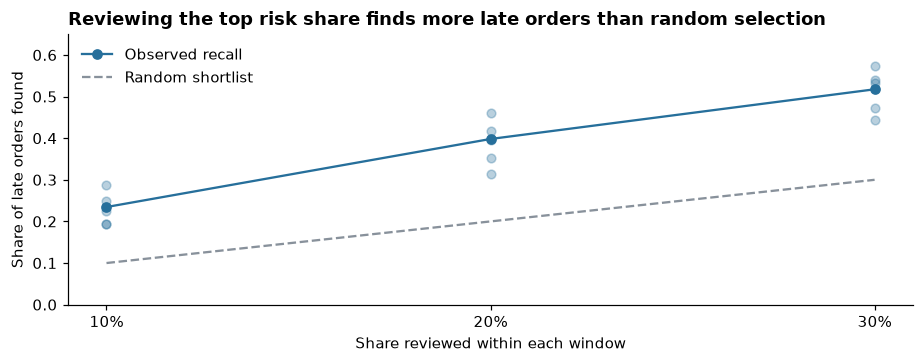

**What this shows.** Reviewing the riskiest **10%** of orders *within each period* finds **951** of **4,054** late orders across the five periods. That is **23.5%** of late orders and **2.34 times** as many as a random list of the same size. This supports using scores to prioritise review; it does not prove an alert would help in practice.

In [32]:
overall = ranking[ranking.scope.eq("all_folds")].sort_values("top_share")
view = overall[["top_share","flagged","caught","recall","precision","lift"]].rename(columns={
    "top_share":"Share reviewed", "flagged":"Orders reviewed", "caught":"Late orders found",
    "recall":"Share of late orders found", "precision":"Share of reviewed orders late", "lift":"Lift vs random"})
display(view.style.format({"Share reviewed":"{:.0%}","Share of late orders found":"{:.1%}",
                           "Share of reviewed orders late":"{:.1%}","Lift vs random":"{:.2f}×"}).hide(axis="index"))
fig,ax=plt.subplots(figsize=(8.5,3.4))
ax.plot(overall.top_share,overall.recall,"o-",color=LINEAR,label="Observed recall")
ax.plot(overall.top_share,overall.top_share,"--",color=BASE,label="Random shortlist")
for f in sorted(predictions.fold.unique()):
    d=ranking[ranking.scope.eq(f"fold_{f}")].sort_values("top_share")
    ax.scatter(d.top_share,d.recall,color=LINEAR,alpha=.32,s=32)
ax.set_xticks(overall.top_share,[f"{x:.0%}" for x in overall.top_share]);ax.set_ylim(0,.65)
ax.set_xlabel("Share reviewed within each window");ax.set_ylabel("Share of late orders found")
ax.legend(frameon=False)
ax.set_title("Reviewing the top risk share finds more late orders than random selection",loc="left")
plt.tight_layout();plt.show()
display(Markdown(f"**What this shows.** Reviewing the riskiest **{top10.top_share:.0%}** of orders "
                 f"*within each period* finds **{top10.caught:,}** of **{top10.late:,}** late orders across the five periods. "
                 f"That is **{top10.recall:.1%}** of late orders and **{top10.lift:.2f} times** as many as "
                 "a random list of the same size. This supports using scores to prioritise review; it does not prove an alert would help in practice."))


The review-list table and plot show more late orders found than random shortlists of the same size. A different view is a yes/no alert rule: the next figure shows how **precision falls as we try to catch more late orders**, and the following bars count correct alerts, false alerts and misses at the provisional cutoff. These are pooled validation results, unlike the model-choice averages above.


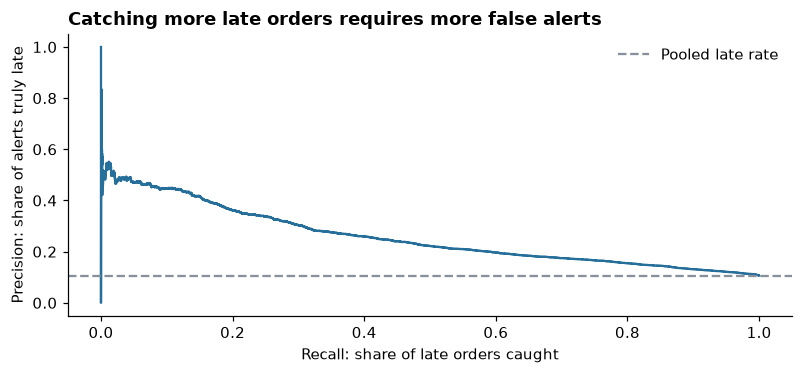

In [33]:
precision, recall, _ = precision_recall_curve(predictions.is_late, predictions.probability)
pooled_rate=predictions.is_late.mean()
fig,ax=plt.subplots(figsize=(7.4,3.5))
ax.plot(recall,precision,color=LINEAR)
ax.axhline(pooled_rate,color=BASE,ls="--",label="Pooled late rate")
ax.set_xlabel("Recall: share of late orders caught")
ax.set_ylabel("Precision: share of alerts truly late")
ax.legend(frameon=False)
ax.set_title("Catching more late orders requires more false alerts",loc="left")
plt.tight_layout();plt.show()


On this **pooled validation** curve, moving right means catching more late orders; moving down means a smaller share of alerts are right. The dashed line is the late share among all pooled validation orders. The curve does not select an operational cutoff. The next display shows the workload at the provisional MCC cutoff chosen above.


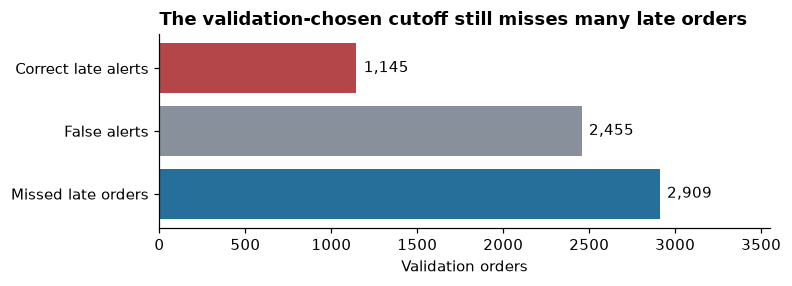

**What this shows.** The chosen alert cutoff flags **3,600** validation orders. It catches **1,145** late orders, sends **2,455** false alerts and misses **2,909** late orders. Across all five periods combined, precision is **31.8%**, recall is **28.2%** and MCC is **0.222**. We picked and measured this cutoff on the same validation results, so these alert scores may look too good. The model-choice PR-AUC above is instead the average of five separate period scores.

In [34]:
chosen_threshold=thresholds[thresholds.rule.eq("validation_selected_mcc")].iloc[0]
fig,ax=plt.subplots(figsize=(7.3,2.7))
counts=[chosen_threshold.true_positive,chosen_threshold.false_positive,chosen_threshold.false_negative]
names=["Correct late alerts","False alerts","Missed late orders"]
ax.barh(names[::-1],counts[::-1],color=[LATE,BASE,LINEAR][::-1])
for y,n in enumerate(counts[::-1]):ax.text(n+max(counts)*.015,y,f"{int(n):,}",va="center")
ax.set_xlim(0,max(counts)*1.22);ax.set_xlabel("Validation orders")
ax.set_title("The validation-chosen cutoff still misses many late orders",loc="left")
plt.tight_layout();plt.show()
alerts=int(chosen_threshold.true_positive+chosen_threshold.false_positive)
display(Markdown(f"**What this shows.** The chosen alert cutoff flags **{alerts:,}** validation orders. "
                 f"It catches **{int(chosen_threshold.true_positive):,}** late orders, sends **{int(chosen_threshold.false_positive):,}** "
                 f"false alerts and misses **{int(chosen_threshold.false_negative):,}** late orders. "
                 f"Across all five periods combined, precision is **{chosen_threshold.precision:.1%}**, "
                 f"recall is **{chosen_threshold.recall:.1%}** and MCC is **{chosen_threshold.mcc:.3f}**. "
                 "We picked and measured this cutoff on the same validation results, so these alert scores may look too good. "
                 "The model-choice PR-AUC above is instead the average of five separate period scores."))


We have now compared models, feature changes and two possible ways to use their scores. The next summary draws the main numbers from the live calculations above, so its figures stay consistent with this run.


In [35]:
base = final_summary.loc["prior_baseline", "mean_average_precision"]
chosen = final_summary.loc[selected, "mean_average_precision"]
forest_ap = final_summary.loc[family_winners["tree_based"], "mean_average_precision"]
top10 = ranking.query('scope == "all_folds" and top_share == 0.1').iloc[0]
train_rate = months["late_orders"].sum() / months["orders"].sum()
display(Markdown(f"""**What the validation work supports**

- The prior-only baseline scores **{base:.3f}** mean per-window PR-AUC; the provisionally selected logistic model scores **{chosen:.3f}**.
- The leading forest scores **{forest_ap:.3f}** on those same later periods. Their gap is too small to call a clear winner.
- Reviewing the riskiest **{top10['top_share']:.0%}** of orders *within each period* finds **{top10['recall']:.1%}** of its late orders, about **{top10['lift']:.1f} times** a random list of the same size.
- Late rates change over time, and some causes of delay occur after checkout. These are validation findings for eventually delivered orders; the final test remains reserved.

The useful role of these scores is **prioritising review**. We have not confirmed a final alert rule or measured the benefit of intervening."""))


**What the validation work supports**

- The prior-only baseline scores **0.107** mean per-window PR-AUC; the provisionally selected logistic model scores **0.200**.
- The leading forest scores **0.200** on those same later periods. Their gap is too small to call a clear winner.
- Reviewing the riskiest **10%** of orders *within each period* finds **23.5%** of its late orders, about **2.3 times** a random list of the same size.
- Late rates change over time, and some causes of delay occur after checkout. These are validation findings for eventually delivered orders; the final test remains reserved.

The useful role of these scores is **prioritising review**. We have not confirmed a final alert rule or measured the benefit of intervening.

## 12. Why online Olist scores are hard to compare

Other published Olist projects use different prediction moments and splits. [ArmutS](https://github.com/ArmutS/olist-delivery-risk) predicts at approval rather than checkout; [Haneen Dahbour](https://github.com/HaneenDahbour/olist-late-delivery-mlops) describes weaker results on later orders; [junxuanc](https://github.com/junxuanc/olist-delay-prediction-analysis) uses a random split. These are examples of **different questions**, not a league table for our PR-AUC. Our own candidates are compared on the same later validation periods.


## 13. What the validation results cannot promise

- The model is about orders that were eventually delivered. It does not estimate the full risk of cancellation or non-delivery at checkout.
- Source timestamps do not prove that every retained field, especially payment and promised-date information, existed exactly as recorded at checkout.
- Late rates change over time. The reserved later test also does not cover the earlier peak shopping season.
- Slow deliveries near the end of the data may still be missing. The validation buffer reduces this risk but cannot remove it completely.
- We chose inputs, models and an alert cutoff using validation. Those numbers guide choices; they are not an independent final result.
- We have not measured staff workload or the cost of false and missed alerts.

Next, compare delivery-time regression and a linear-plus-forest voting model. Only after those choices are fixed should the reserved later-period test be scored.


## 14. Reproduce the saved reference run

The models above ran visibly in this notebook. We now compare their scores, predictions, selected cutoff, shortlists and interpretation results with the separately saved reference files. Each row below says whether one kind of result matches. This checks reproduction of the same computation; it does not make validation an independent final test.


In [36]:
def saved(name):
    return pd.read_csv(RESULT_DIR / f"{name}.csv")

saved_summary = saved("cv_summary").set_index("candidate")
saved_ladder = saved("ladder_summary")
saved_predictions = saved("selected_validation_predictions")
saved_threshold = saved("threshold_metrics")
saved_splits = saved("split_comparison")
saved_ranking = saved("risk_ranking")
saved_odds = saved("logistic_odds_ratios")
saved_importance = saved("forest_permutation_importance")
checks = {}
checks["candidate mean PR-AUC"] = np.allclose(
    final_summary.loc[saved_summary.index, "mean_average_precision"],
    saved_summary["mean_average_precision"], rtol=0, atol=1e-10)
checks["candidate mean ROC-AUC"] = np.allclose(
    final_summary.loc[saved_summary.index, "mean_roc_auc"],
    saved_summary["mean_roc_auc"], rtol=0, atol=1e-10)
for column in ["mean_average_precision", "mean_roc_auc", "mean_ap_over_late_rate", "delta_average_precision"]:
    checks[f"ladder {column}"] = np.allclose(
        ladder_summary[column], saved_ladder[column], equal_nan=True, rtol=0, atol=1e-10)
checks["validation probabilities"] = (oof[["order_id","fold","is_late"]].equals(
    saved_predictions[["order_id","fold","is_late"]]) and np.allclose(
    oof["probability"], saved_predictions["probability"], rtol=0, atol=1e-10))
checks["selected threshold"] = np.isclose(
    threshold, saved_threshold.loc[saved_threshold.rule.eq("validation_selected_mcc"), "threshold"].iloc[0],
    rtol=0, atol=1e-10)
checks["random comparison"] = np.allclose(
    splits[["mean_average_precision","mean_roc_auc"]],
    saved_splits[["mean_average_precision","mean_roc_auc"]], rtol=0, atol=1e-10)
checks["risk ranking"] = np.allclose(ranking[["recall","precision","lift"]],
                                      saved_ranking[["recall","precision","lift"]], rtol=0, atol=1e-10)
checks["logistic odds ratios"] = np.allclose(odds["odds_ratio"], saved_odds["odds_ratio"],
                                             rtol=0, atol=1e-10)
checks["forest importance"] = np.allclose(importance["importance_mean"],
                                           saved_importance["importance_mean"], rtol=0, atol=1e-10)
display(pd.DataFrame({"comparison": list(checks), "matches saved result": list(checks.values())})
        .style.hide(axis="index"))
assert all(checks.values()), {key: ok for key, ok in checks.items() if not ok}
print("Selected candidate:", selected)
print("All live-versus-saved checks passed. No later-period test score was calculated.")

comparison,matches saved result
candidate mean PR-AUC,True
candidate mean ROC-AUC,True
ladder mean_average_precision,True
ladder mean_roc_auc,True
ladder mean_ap_over_late_rate,True
ladder delta_average_precision,True
validation probabilities,True
selected threshold,True
random comparison,True
risk ranking,True


Selected candidate: logistic_c01
All live-versus-saved checks passed. No later-period test score was calculated.


Every live-versus-saved comparison passed. The match includes the selected validation probabilities, feature ladder, threshold and interpretation calculations. At this stage, the reserved later-period test has not been scored. The final section opens it after the model choices are fixed.


## 15. Rerunning this work

Run the notebook from a fresh Python kernel in the project environment. [Data preparation](data_prep.ipynb) and `phase2_features.py` show how earlier-order features were built. `phase2_classification.py` is a separate command-line reference; the fitting and scoring code above is visible and runnable here. The next cell prints the seed, Python and scikit-learn versions, and the number of date-ordered checks so a reader can identify the run.


In [37]:
print(f"Seed: {spec['random_state']}; Python: {platform.python_version()}; scikit-learn: {sklearn.__version__}")
print(f"Chronological validation windows: {len(folds)}")
print("The final model fit and later-period test are shown in the final section below.")

Seed: 42; Python: 3.14.7; scikit-learn: 1.9.1
Chronological validation windows: 5
The final model fit and later-period test are shown in the final section below.


The printed setup confirms the fixed seed and date-ordered validation count. The next section gives the one final check on later purchases.

## Final held-out evaluation

The model, features and alert cutoff were chosen from the five earlier validation windows. We now fit the selected logistic model on all 75,099 eligible primary training orders and score the later test period once. The test result describes performance on later purchases; it did not influence any choice above.

In [38]:
RUN_FINAL_HELD_OUT = True  # Model, features and threshold were frozen before opening the test period.

if RUN_FINAL_HELD_OUT:
    table = pd.read_csv(ROOT / "data/phase2_order_table.csv")
    test = table.loc[table[spec["primary_split"]].eq("test")].copy()
    family, params = candidate[selected]
    numeric, categorical = feature_columns(spec, True, stages["seller"])
    final_pipeline = make_pipeline(family, params, spec, feature_set=stages["seller"],
                                   log_features=final_log)
    with threadpool_limits(limits=1):
        final_pipeline.fit(train[numeric + categorical], train[spec["classification_target"]])
        test_probability = final_pipeline.predict_proba(test[numeric + categorical])[:, 1]
    held_out_metrics = metrics(test[spec["classification_target"]], test_probability, threshold)
    print(f"Test orders: {len(test):,}; late orders: {int(test[spec['classification_target']].sum()):,}")
    display(pd.DataFrame([held_out_metrics]).style.format(precision=3).hide(axis="index"))
    print("HELD_OUT_METRICS=" + json.dumps(held_out_metrics, sort_keys=True))
else:
    print("Final held-out evaluation remains OFF; no test-period rows were scored.")

Test orders: 19,363; late orders: 674


average_precision,roc_auc,precision,recall,f1,mcc,true_negative,false_positive,false_negative,true_positive
0.065,0.668,0.052,0.644,0.097,0.082,10807,7882,240,434


HELD_OUT_METRICS={"average_precision": 0.0651267024932204, "f1": 0.09655172413793103, "false_negative": 240, "false_positive": 7882, "mcc": 0.08226818470551678, "precision": 0.05218855218855219, "recall": 0.6439169139465876, "roc_auc": 0.6679838963334404, "true_negative": 10807, "true_positive": 434}


The later test period contains **19,363 delivered orders**, of which **674 (3.48%)** were late. The selected model achieves **PR-AUC 0.0651** (versus 0.0348 for a constant-risk ranking) and **ROC-AUC 0.668**. It still separates late from on-time orders better than a random ranking.

The validation-selected cutoff of **0.0788** does not work well as a yes/no alert on this period. It flags **8,316 orders (42.9%)**: 434 are late and 7,882 are on time; it misses 240 late orders. Precision is **5.2%**, recall **64.4%**, F1 **0.097**, and MCC **0.082**. The late-order rate is much lower here than across the validation windows, and the alert scores are weaker. We report this result as the final check; choosing a new cutoff from these test labels would turn the held-out set into tuning data.